# Phase 1: Dataset Preparation and Analysis

Done! Press the Refresh button if files are not visible.

SCANNING DATASET FOLDERS
Folder 0-FFHQ: 300 REAL images
Folder 1-StarGAN: 300 FAKE images
Folder 0-CelebA: 300 REAL images
Folder 1-ATTGAN: 300 FAKE images

PRELIMINARY DATASET ANALYSIS
Total REAL images (class 0): 600
Total FAKE images (class 1): 600
Total images: 1200
Balance: 50.0% real, 50.0% fake


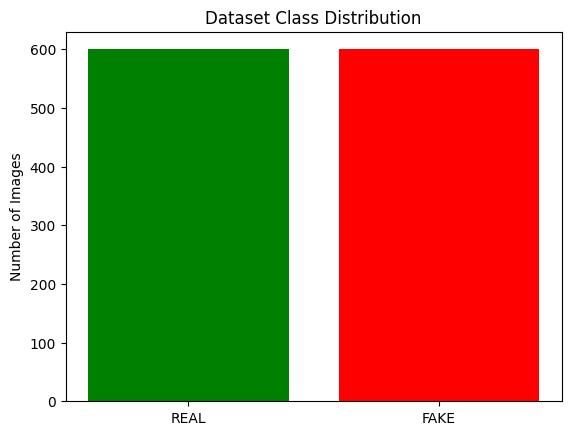

In [ ]:
# Import libraries
import random
import cv2
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from IPython.display import HTML, display, clear_output
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

random.seed(123)
np.random.seed(123)

# Progress bar function
def progress(value, max=100):
  return HTML("""<progress value='{value}' max='{max}', style='width: 100%'>
        {value}
    </progress>""".format(value=value, max=max))

# Google Drive authentication
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Download dataset
print("Downloading dataset...")
downloaded = drive.CreateFile({'id': '1hyLB0LJURdLfKKskGRcFyHAcAK19W5Jy'})
downloaded.GetContentFile('deepfakes_db.zip')
print("Download completed!")

# Unzip
!unzip -q deepfakes_db.zip
clear_output()
print('Done! Press the Refresh button if files are not visible.')

# Dataset analysis: count samples per class
path = "/content/deepfakes_db/"
folders = os.listdir(path)

count_real = 0
count_fake = 0

print("\n" + "="*60)
print("SCANNING DATASET FOLDERS")
print("="*60)

for folder in folders:
  folder_path = os.path.join(path, folder)
  if not os.path.isdir(folder_path):
    continue

  num_images = len([f for f in os.listdir(folder_path)
                if f.endswith(('.jpg', '.png', '.jpeg'))])

  if folder.startswith("0"):
    count_real += num_images
    print(f"Folder {folder}: {num_images} REAL images")
  elif folder.startswith("1"):
    count_fake += num_images
    print(f"Folder {folder}: {num_images} FAKE images")

# Final summary
print("\n" + "="*60)
print("PRELIMINARY DATASET ANALYSIS")
print("="*60)
print(f"Total REAL images (class 0): {count_real}")
print(f"Total FAKE images (class 1): {count_fake}")
print(f"Total images: {count_real + count_fake}")
print(f"Balance: {(count_real/(count_real+count_fake))*100:.1f}% real, {(count_fake/(count_real+count_fake))*100:.1f}% fake")
print("="*60)

# Visualization
plt.bar(['REAL', 'FAKE'], [count_real, count_fake], color=['green', 'red'])
plt.title('Dataset Class Distribution')
plt.ylabel('Number of Images')
plt.show()

The dataset is perfectly balanced: 600 real images and 600 fake images, for a total of 1,200 images.  
The real images come from two sources (CelebA and FFHQ), while the fake images are generated by two GAN algorithms (AttGAN and StarGAN). The folder structure directly encodes the binary label — folders prefixed with "0" for real, "1" for fake.  
The perfect class balance eliminates classification bias and makes accuracy a reliable evaluation metric.  

# Phase 2: Implementation of the Deepfake Detection Systems

In [ ]:
# CNN architecture: 2 convolutional blocks + fully connected layer
# Input: 100x100 images (RGB or Grayscale)
# Output: 2 classes (Real/Fake) with softmax activation
tf.random.set_seed(123)

def create_cnn(input_shape):
  model = Sequential()
  model.add(Conv2D(32, (3, 3), input_shape=input_shape))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))          # dropout to reduce overfitting
  model.add(Conv2D(64, (3, 3)))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Dropout(0.5))           # higher dropout in deeper layer
  model.add(Flatten())
  model.add(Dense(2))
  model.add(Activation('softmax'))  # softmax for binary classification
  return model

# RGB model: input shape (100, 100, 3)
model_rgb = create_cnn((100, 100, 3))
# Grayscale model: input shape (100, 100, 1)
model_gray = create_cnn((100, 100, 1))

# Adam optimizer with MSE loss, consistent with lab approach
model_rgb.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
model_gray.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

model_rgb.summary()
model_gray.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        67,714 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,106 (340.26 KB)

 Trainable params: 87,106 (340.26 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 98, 98, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 47, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │        67,714 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,530 (338.01 KB)

 Trainable params: 86,530 (338.01 KB)

 Non-trainable params: 0 (0.00 B)

Both models share the same architecture — they differ only in the input shape:

- **RGB**: input (100, 100, 3) → 87,106 trainable parameters
- **Grayscale**: input (100, 100, 1) → 86,530 trainable parameters

The architecture consists of two convolutional blocks followed by a fully connected layer:

1. **Block 1**: Conv2D(32, 3×3) → ReLU → MaxPooling(2×2) → Dropout(0.25)
2. **Block 2**: Conv2D(64, 3×3) → ReLU → MaxPooling(2×2) → Dropout(0.50)
3. **Classifier**: Flatten → Dense(2) → Softmax

**Design choices:**
- **Increasing dropout (0.25 → 0.50)**: the first convolutional block applies light dropout to preserve low-level features; the second applies more aggressive dropout where the network is more prone to overfitting
- **MSE loss**: treats the softmax output as a continuous vector to be pulled toward the one-hot encoding of the true label, penalizing the distance between prediction and target proportionally
- **Adam optimizer**: adapts the learning rate per parameter during training, combining the advantages of momentum and RMSProp
- **np.argmax post-processing**: converts the softmax probability vector into a discrete prediction by selecting the class with the highest score

# Phase 3: Training, Validation and Testing

Loading images...
Total images loaded: 1200
Class 0 (REAL): 600
Class 1 (FAKE): 600

Train set: 720
Validation set: 240
Test set: 240
No pre-trained models found — training from scratch...

Training RGB MODEL...
Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.6069 - loss: 0.2662 - val_accuracy: 0.7708 - val_loss: 0.1978
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.8236 - loss: 0.1226 - val_accuracy: 0.9292 - val_loss: 0.0794
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9389 - loss: 0.0456 - val_accuracy: 0.9458 - val_loss: 0.0442
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9778 - loss: 0.0222 - val_accuracy: 0.9625 - val_loss: 0.0337
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.9861 - loss: 0.0130 - val_accuracy: 0.9333 - val_loss: 0.0457
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.9875 - loss: 0.0101 - val_accuracy: 0.9583 - val_loss: 0.0298
Epoch 7/50

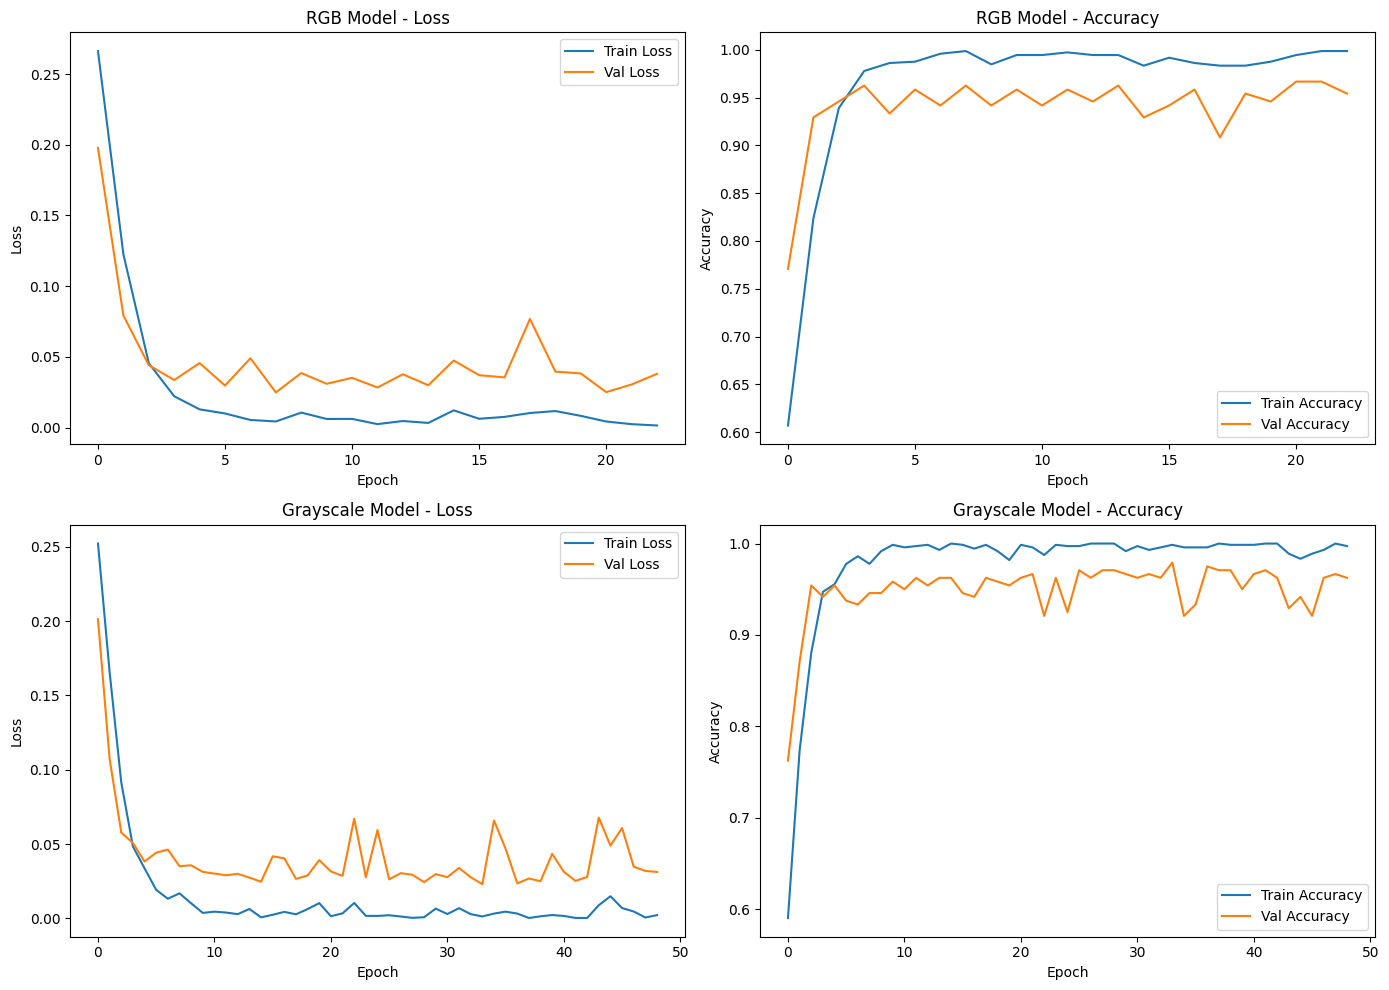

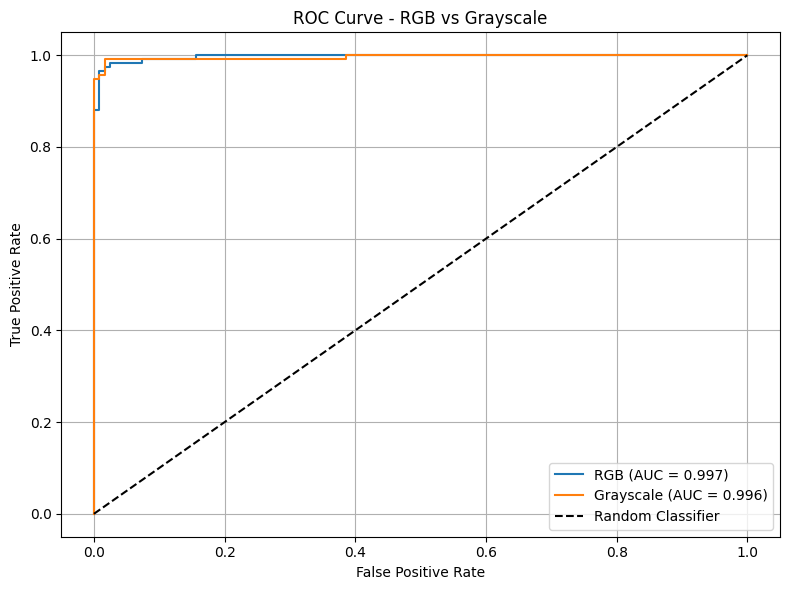

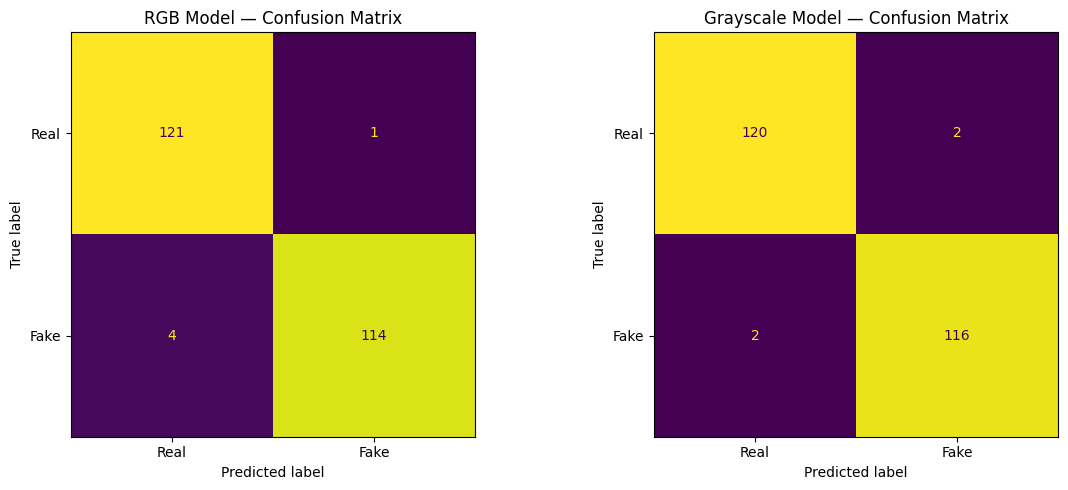

In [ ]:
# Load images directly without face detection
# The dataset already contains cropped face images
path = "/content/deepfakes_db/"
folders = sorted(os.listdir(path))

data = []
labels = []

print("Loading images...")

for folder in folders:
  folder_path = os.path.join(path, folder)
  if not os.path.isdir(folder_path):
    continue

  images = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

  for image in images:
    img_path = os.path.join(folder_path, image)
    img = cv2.imread(img_path)
    if img is None:
      continue
    # Resize to 100x100
    face = cv2.resize(img, (100, 100))
    data.append(face)
    # Folders starting with "0" are real, "1" are fake
    if folder.startswith("0"):
      labels.append(0)
    else:
      labels.append(1)

X = np.array(data)
y = np.array(labels)

print(f"Total images loaded: {len(X)}")
print(f"Class 0 (REAL): {np.sum(y==0)}")
print(f"Class 1 (FAKE): {np.sum(y==1)}")

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Further split train into train (60%) and validation (20%)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

print(f"\nTrain set: {len(X_train)}")
print(f"Validation set: {len(X_val)}")
print(f"Test set: {len(X_test)}")

# Normalize to [0,1]
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32')   / 255.0
X_test = X_test.astype('float32')  / 255.0

# Min-max normalization using training set statistics
min_val = np.min(X_train)
max_val = np.max(X_train)
X_train = (X_train - min_val) / (max_val - min_val)
X_val = (X_val   - min_val) / (max_val - min_val)
X_test = (X_test  - min_val) / (max_val - min_val)

# One-hot encoding: convert labels to categorical vectors
y_train_c = to_categorical(y_train, 2)
y_val_c = to_categorical(y_val,   2)
y_test_c = to_categorical(y_test,  2)

# Convert RGB images to grayscale by averaging the 3 channels
X_train_gray = np.mean(X_train, axis=3, keepdims=True)
X_val_gray = np.mean(X_val,   axis=3, keepdims=True)
X_test_gray = np.mean(X_test,  axis=3, keepdims=True)

# Load pre-trained models if available, otherwise train from scratch
history_rgb = None
history_gray = None

# Create models directory if it does not exist
os.makedirs('models', exist_ok=True)

if (os.path.exists('models/model_rgb.keras') and
  os.path.exists('models/model_gray.keras') and
  os.path.exists('models/test_data.npz')    and
  os.path.exists('models/history.npz')):

  print("Pre-trained models found — loading from disk...")
  model_rgb  = tf.keras.models.load_model('models/model_rgb.keras')
  model_gray = tf.keras.models.load_model('models/model_gray.keras')

  # Reload saved splits and normalization — ensures consistency with training
  d = np.load('models/test_data.npz')
  X_test=d['X_test']
  X_test_gray=d['X_test_gray']
  X_val=d['X_val']
  X_val_gray=d['X_val_gray']
  X_train=d['X_train']
  X_train_gray=d['X_train_gray']
  y_test=d['y_test']
  y_val=d['y_val']
  y_train=d['y_train']
  y_test_c=d['y_test_c']
  y_val_c=d['y_val_c']
  y_train_c=d['y_train_c']

  # Reload training history for plot reproducibility
  h = np.load('models/history.npz')
  history_rgb = {'loss': h['rgb_loss'],  'val_loss': h['rgb_val_loss'],
                  'accuracy': h['rgb_acc'], 'val_accuracy': h['rgb_val_acc']}
  history_gray = {'loss': h['gray_loss'], 'val_loss': h['gray_val_loss'],
                  'accuracy': h['gray_acc'], 'val_accuracy': h['gray_val_acc']}

  print("Models loaded successfully.")

else:
  print("No pre-trained models found — training from scratch...")
  # Early stopping to prevent overfitting: monitor validation loss with patience=15
  early_stop_rgb = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
  early_stop_gray = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

  # Train models
  print("\n" + "="*60)
  print("Training RGB MODEL...")
  print("="*60)
  history_rgb_obj = model_rgb.fit(
    X_train, y_train_c,
    batch_size=4, epochs=50, verbose=1,
    validation_data=(X_val, y_val_c),
    callbacks=[early_stop_rgb])

  print("\n" + "="*60)
  print("Training GRAYSCALE MODEL...")
  print("="*60)
  history_gray_obj = model_gray.fit(
    X_train_gray, y_train_c,
    batch_size=4, epochs=50, verbose=1,
    validation_data=(X_val_gray, y_val_c),
    callbacks=[early_stop_gray])

  # Save trained models to disk for reproducibility
  model_rgb.save('models/model_rgb.keras')
  model_gray.save('models/model_gray.keras')
  print("Models saved successfully.")

  # Save data splits and normalization for use in attack notebook
  np.savez('models/test_data.npz',
          X_test=X_test,
          X_test_gray=X_test_gray,
          X_val=X_val,
          X_val_gray=X_val_gray,
          X_train=X_train,
          X_train_gray=X_train_gray,
          y_test=y_test,
          y_val=y_val,
          y_train=y_train,
          y_test_c=y_test_c,
          y_val_c=y_val_c,
          y_train_c=y_train_c)

  # Save training history for plot reproducibility
  np.savez('models/history.npz',
          rgb_loss=history_rgb_obj.history['loss'],
          rgb_val_loss=history_rgb_obj.history['val_loss'],
          rgb_acc=history_rgb_obj.history['accuracy'],
          rgb_val_acc=history_rgb_obj.history['val_accuracy'],
          gray_loss=history_gray_obj.history['loss'],
          gray_val_loss=history_gray_obj.history['val_loss'],
          gray_acc=history_gray_obj.history['accuracy'],
          gray_val_acc=history_gray_obj.history['val_accuracy'])

  # Convert to plain dict for uniform access below
  history_rgb = history_rgb_obj.history
  history_gray = history_gray_obj.history

# Evaluate both models on the test set
print("\n" + "="*60)
print("EVALUATION ON TEST SET")
print("="*60)
loss_rgb,  acc_rgb_keras = model_rgb.evaluate(X_test, y_test_c, verbose=0)
loss_gray, acc_gray_keras = model_gray.evaluate(X_test_gray, y_test_c, verbose=0)
print(f"RGB Model       - Loss: {loss_rgb:.4f} | Accuracy: {acc_rgb_keras*100:.2f}%")
print(f"Grayscale Model - Loss: {loss_gray:.4f} | Accuracy: {acc_gray_keras*100:.2f}%")

# Get predictions for ROC curve and gallery
scores_rgb = model_rgb.predict(X_test)
scores_gray = model_gray.predict(X_test_gray)

y_pred_rgb = np.argmax(scores_rgb,  axis=1)
y_pred_gray = np.argmax(scores_gray, axis=1)

# Plot training history for both models
if history_rgb is not None and history_gray is not None:
  fig, axes = plt.subplots(2, 2, figsize=(14, 10))

  axes[0,0].plot(history_rgb['loss'],     label='Train Loss')
  axes[0,0].plot(history_rgb['val_loss'], label='Val Loss')
  axes[0,0].set_title('RGB Model - Loss')
  axes[0,0].set_xlabel('Epoch')
  axes[0,0].set_ylabel('Loss')
  axes[0,0].legend()

  axes[0,1].plot(history_rgb['accuracy'],     label='Train Accuracy')
  axes[0,1].plot(history_rgb['val_accuracy'], label='Val Accuracy')
  axes[0,1].set_title('RGB Model - Accuracy')
  axes[0,1].set_xlabel('Epoch')
  axes[0,1].set_ylabel('Accuracy')
  axes[0,1].legend()

  axes[1,0].plot(history_gray['loss'],     label='Train Loss')
  axes[1,0].plot(history_gray['val_loss'], label='Val Loss')
  axes[1,0].set_title('Grayscale Model - Loss')
  axes[1,0].set_xlabel('Epoch')
  axes[1,0].set_ylabel('Loss')
  axes[1,0].legend()

  axes[1,1].plot(history_gray['accuracy'],     label='Train Accuracy')
  axes[1,1].plot(history_gray['val_accuracy'], label='Val Accuracy')
  axes[1,1].set_title('Grayscale Model - Accuracy')
  axes[1,1].set_xlabel('Epoch')
  axes[1,1].set_ylabel('Accuracy')
  axes[1,1].legend()

  plt.tight_layout()
  plt.show()

# ROC Curve: compare both models
fpr_rgb, tpr_rgb, _ = roc_curve(y_test, scores_rgb[:,1])
fpr_gray, tpr_gray, _ = roc_curve(y_test, scores_gray[:,1])
auc_rgb = auc(fpr_rgb, tpr_rgb)
auc_gray = auc(fpr_gray, tpr_gray)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rgb, tpr_rgb, label=f'RGB (AUC = {auc_rgb:.3f})')
plt.plot(fpr_gray, tpr_gray, label=f'Grayscale (AUC = {auc_gray:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - RGB vs Grayscale')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrices: show classification performance on test set for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rgb),
                       display_labels=['Real', 'Fake']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('RGB Model — Confusion Matrix')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gray),
                       display_labels=['Real', 'Fake']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Grayscale Model — Confusion Matrix')

plt.tight_layout()
plt.show()

## Pre-processing
Images are resized to 100×100 pixels and undergo double normalization:
1. **Division by 255** → maps values into the [0, 1] range
2. **Min-max normalization** computed on training set statistics → ensures validation and test sets are normalized with the same parameters as training, avoiding data leakage

Grayscale is obtained by averaging the 3 RGB channels (`np.mean(axis=3)`), keeping the channel dimension (`keepdims=True`).

Labels are one-hot encoded to be compatible with MSE loss.

## Split
| Set | Images | Percentage |
|-----|--------|------------|
| Training | 720 | 60% |
| Validation | 240 | 20% |
| Test | 240 | 20% |

The dataset was initially split 80/20 between training and test. The training set was then further split 75/25, yielding a validation set equal to 20% of the total — used exclusively to monitor early stopping during training.

## Training
- **Early stopping** independently for the two models (patience=15 on val_loss, restore_best_weights=True)
- **Batch size**: 4
- **Max epochs**: 50

| Model | Accuracy | AUC | Loss | Final epoch |
|-------|----------|-----|------|-------------|
| RGB | 97.92% | 0.997 | 0.0191 | 23 |
| Grayscale | 98.33% | 0.996 | 0.0139 | 49 |

# Phase 4: Results Analysis



Total misclassified by the models: 7


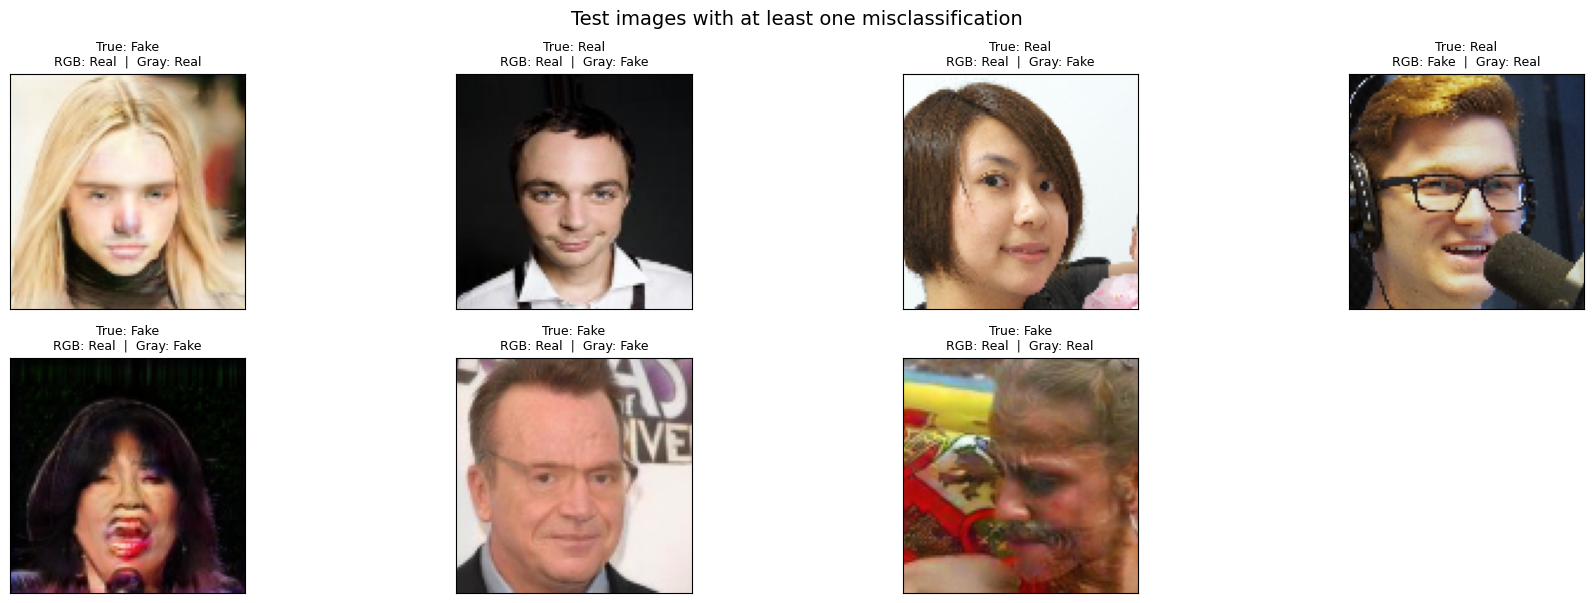

In [ ]:
# Helper function to convert numeric label to string
def label(num):
  if num == 1:
    return "Fake"
  else:
    return "Real"

# Find images where at least one model made an error
errors = []
for i in range(len(X_test)):
  rgb_wrong  = y_pred_rgb[i] != y_test[i]
  gray_wrong = y_pred_gray[i] != y_test[i]
  if rgb_wrong or gray_wrong:
    errors.append(i)

print(f"Total misclassified by the models: {len(errors)}")

# Pick up to 12 errors to display
selected = errors[:12]

n_cols = 4
n_rows = 3
plt.figure(figsize=(4.5*n_cols, 3*n_rows))

for idx, i in enumerate(selected):
  plt.subplot(n_rows, n_cols, idx+1)
  plt.tick_params(axis='both', left=False, top=False, right=False, bottom=False,
                labelleft=False, labeltop=False, labelright=False, labelbottom=False)
  # Show true label and predictions from both models
  plt.title(
    f"True: {label(y_test[i])}\n"
    f"RGB: {label(y_pred_rgb[i])}  |  Gray: {label(y_pred_gray[i])}",
    fontsize=9
  )
  # Convert BGR to RGB for correct color display
  image = cv2.cvtColor(X_test[i], cv2.COLOR_BGR2RGB)
  plt.imshow(image)

plt.suptitle("Test images with at least one misclassification", fontsize=14)
plt.tight_layout()
plt.show()

The gallery shows the test set images where at least one of the two models misclassified. For each image the true label and both model predictions are reported.

**Total errors:** 7 images out of 240 (RGB: 5 errors, Grayscale: 4 errors, with 2 images misclassified by both)

## Summary of Results
- **RGB Model**: Accuracy = 97.92%, AUC = 0.997, early stop epoch 23, 5 errors (1 FP + 4 FN)
- **Grayscale Model**: Accuracy = 98.33%, AUC = 0.996, early stop epoch 49, 4 errors (2 FP + 2 FN)

Both models achieve strong results on the test set, with 5 errors for the RGB model and 4 for the Grayscale model out of 240 test images.

## Strengths
**RGB Model**
- Uses color information, which can help identify visual imperfections typical of deepfake images, such as unnatural skin tones or artifacts around face edges
- Has more information per pixel thanks to the 3 color channels

**Grayscale Model**
- Achieves slightly better results while using less information
- Less affected by lighting and color variations across images
- Trains faster thanks to the single input channel

## Weaknesses
**RGB Model**
- More sensitive to lighting and color differences across images
- The larger number of parameters can cause issues on small datasets

**Grayscale Model**
- Does not exploit color information, which in some cases could help detect a deepfake
- May struggle with deepfakes where the manipulation mainly affects color

## Key Observation
Contrary to what one might expect, the grayscale model slightly outperforms the color one. This suggests that the visual imperfections left by deepfake generation algorithms (AttGAN, StarGAN) are detectable even without color information — removing chromatic noise improves the model's discriminative capability.

# Advanced Component: Adversarial Robustness in DeepFake Detection

## Open Problem
CNN models for deepfake detection are vulnerable to evasion adversarial attacks, both in white-box and black-box scenarios (Masood et al., 2023, Sec. 6.2; Carlini & Farid, 2020; Neekhara et al., 2021). An attacker with full model access can generate imperceptible perturbations via PGD; an attacker without access can exploit the transferability of adversarial examples through a surrogate model. Can these models be hardened via adversarial training while preserving good accuracy on the clean test set?

## Research Hypothesis
A model retrained including PGD-generated adversarial examples in the training loop — a technique known as adversarial training (Madry et al., 2018) — increases robust accuracy under both white-box and black-box attacks compared to the original model, at the cost of a slight reduction in clean accuracy. This trade-off is expected to differ between the RGB and Grayscale models.

## Experimental Approach
1. **White-box PGD** on the original models → security evaluation curve (robust accuracy baseline).
   The attack implements an *untargeted evasion attack* (maximization problem):
   it maximizes the classification loss while constraining the perturbation to the L-∞ ball of radius ε —
   **max L(x+δ, y; θ), s.t. ||δ||∞ ≤ ε** — causing generic misclassification
   with a perturbation imperceptible to the human eye.
2. **Black-box transfer attack** (Biggio et al., 2013; Papernot et al., 2016) → adversarial examples generated on the surrogate model are transferred to the target model without access to its gradients. Transferability is the mechanism that makes the attack effective even without knowledge of the victim model.
3. **Adversarial training** with PGD (Madry et al., 2018) → retraining of both models including adversarial examples in the training loop, implementing the min-max formulation: **min_θ E[max_δ L(x+δ, y; θ)]**.
4. **White-box and black-box PGD** on the defended models → security evaluation curve after adversarial training, to verify whether robustness improves both with and without access to the model.
5. **Comparison** of clean accuracy vs robust accuracy, white-box vs black-box, original vs defended model, RGB vs Grayscale — to quantify the robustness/accuracy trade-off and assess which model benefits most from adversarial training.

## STEP 1: PGD White-box Attack

In [ ]:
# ============================================================
# STEP 1 — PGD ATTACK ON ORIGINAL MODELS
# PGD - Projected Gradient Descent (Madry et al., 2018)
# Iterative white-box evasion attack: at each step, computes
# gradient of loss w.r.t. input, takes a small step in the
# direction that maximizes the loss, then projects back into
# the L-inf ball of radius epsilon around the original image.
# ============================================================

def pgd_attack(model, images, labels, epsilon, alpha=0.01, steps=40):
  images_tensor = tf.cast(images, tf.float32)
  labels_tensor = tf.cast(labels, tf.float32)

  # Random start inside the epsilon ball
  delta = tf.random.uniform(tf.shape(images_tensor), -epsilon, epsilon)
  adv = tf.clip_by_value(images_tensor + delta, 0, 1)

  for _ in range(steps):
    adv_var = tf.Variable(adv)
    with tf.GradientTape() as tape:
      tape.watch(adv_var)
      predictions = model(adv_var)
      # Maximize loss to cause misclassification
      loss = tf.reduce_mean(tf.square(labels_tensor - predictions))

    # Gradient step in direction that maximizes loss
    gradients = tape.gradient(loss, adv_var)
    adv = adv_var + alpha * tf.sign(gradients)

    # Project back into L-inf epsilon ball around original image
    adv = tf.clip_by_value(adv, images_tensor - epsilon, images_tensor + epsilon)
    # Clip to valid pixel range [0,1]
    adv = tf.clip_by_value(adv, 0, 1)

  return adv.numpy()

epsilons = [0.0, 0.01, 0.02, 0.05]

print("="*60)
print("STEP 1 — PGD ATTACK ON ORIGINAL MODELS")
print("="*60)

if os.path.exists('models/pgd_results.npz'):
  print("PGD results found — loading from disk...")
  r = np.load('models/pgd_results.npz')
  epsilons = list(r['epsilons'])
  acc_rgb_orig = list(r['acc_rgb_orig'])
  acc_gray_orig = list(r['acc_gray_orig'])
  auc_rgb_orig = list(r['auc_rgb_orig'])
  auc_gray_orig = list(r['auc_gray_orig'])
  preds_rgb = {
    'eps_0.0':  r['pred_rgb_000'],
    'eps_0.01': r['pred_rgb_001'],
    'eps_0.02': r['pred_rgb_002'],
    'eps_0.05': r['pred_rgb_005']
  }
  preds_gray = {
    'eps_0.0':  r['pred_gray_000'],
    'eps_0.01': r['pred_gray_001'],
    'eps_0.02': r['pred_gray_002'],
    'eps_0.05': r['pred_gray_005']
  }
  for i, eps in enumerate(epsilons):
    print(f"ε={eps:.2f} | RGB Acc: {acc_rgb_orig[i]*100:.2f}% | Gray Acc: {acc_gray_orig[i]*100:.2f}%")

else:
  acc_rgb_orig = []
  acc_gray_orig = []
  auc_rgb_orig = []
  auc_gray_orig = []
  preds_rgb = {}
  preds_gray = {}

  for eps in epsilons:
    X_adv_rgb = pgd_attack(model_rgb, X_test, y_test_c, eps)
    X_adv_gray = pgd_attack(model_gray, X_test_gray, y_test_c, eps)

    scores_rgb = model_rgb.predict(X_adv_rgb, verbose=0)
    scores_gray = model_gray.predict(X_adv_gray, verbose=0)

    y_pred_rgb = np.argmax(scores_rgb, axis=1)
    y_pred_gray = np.argmax(scores_gray, axis=1)

    acc_rgb_orig.append(accuracy_score(y_test, y_pred_rgb))
    acc_gray_orig.append(accuracy_score(y_test, y_pred_gray))

    fpr_r, tpr_r, _ = roc_curve(y_test, scores_rgb[:,1])
    fpr_g, tpr_g, _ = roc_curve(y_test, scores_gray[:,1])
    auc_rgb_orig.append(auc(fpr_r, tpr_r))
    auc_gray_orig.append(auc(fpr_g, tpr_g))

    # Store predictions for confusion matrices in STEP 2
    preds_rgb[f'eps_{eps}'] = y_pred_rgb
    preds_gray[f'eps_{eps}'] = y_pred_gray

    print(f"ε={eps:.2f} | RGB Acc: {acc_rgb_orig[-1]*100:.2f}% | Gray Acc: {acc_gray_orig[-1]*100:.2f}%")

  # Save results and predictions to disk for reproducibility
  np.savez('models/pgd_results.npz',
          epsilons=epsilons,
          acc_rgb_orig=acc_rgb_orig,
          acc_gray_orig=acc_gray_orig,
          auc_rgb_orig=auc_rgb_orig,
          auc_gray_orig=auc_gray_orig,
          pred_rgb_000=preds_rgb['eps_0.0'],
          pred_gray_000=preds_gray['eps_0.0'],
          pred_rgb_001=preds_rgb['eps_0.01'],
          pred_gray_001=preds_gray['eps_0.01'],
          pred_rgb_002=preds_rgb['eps_0.02'],
          pred_gray_002=preds_gray['eps_0.02'],
          pred_rgb_005=preds_rgb['eps_0.05'],
          pred_gray_005=preds_gray['eps_0.05'])

STEP 1 — PGD ATTACK ON ORIGINAL MODELS
ε=0.00 | RGB Acc: 97.92% | Gray Acc: 98.33%
ε=0.01 | RGB Acc: 62.08% | Gray Acc: 71.67%
ε=0.02 | RGB Acc: 9.58% | Gray Acc: 20.83%
ε=0.05 | RGB Acc: 0.00% | Gray Acc: 0.00%


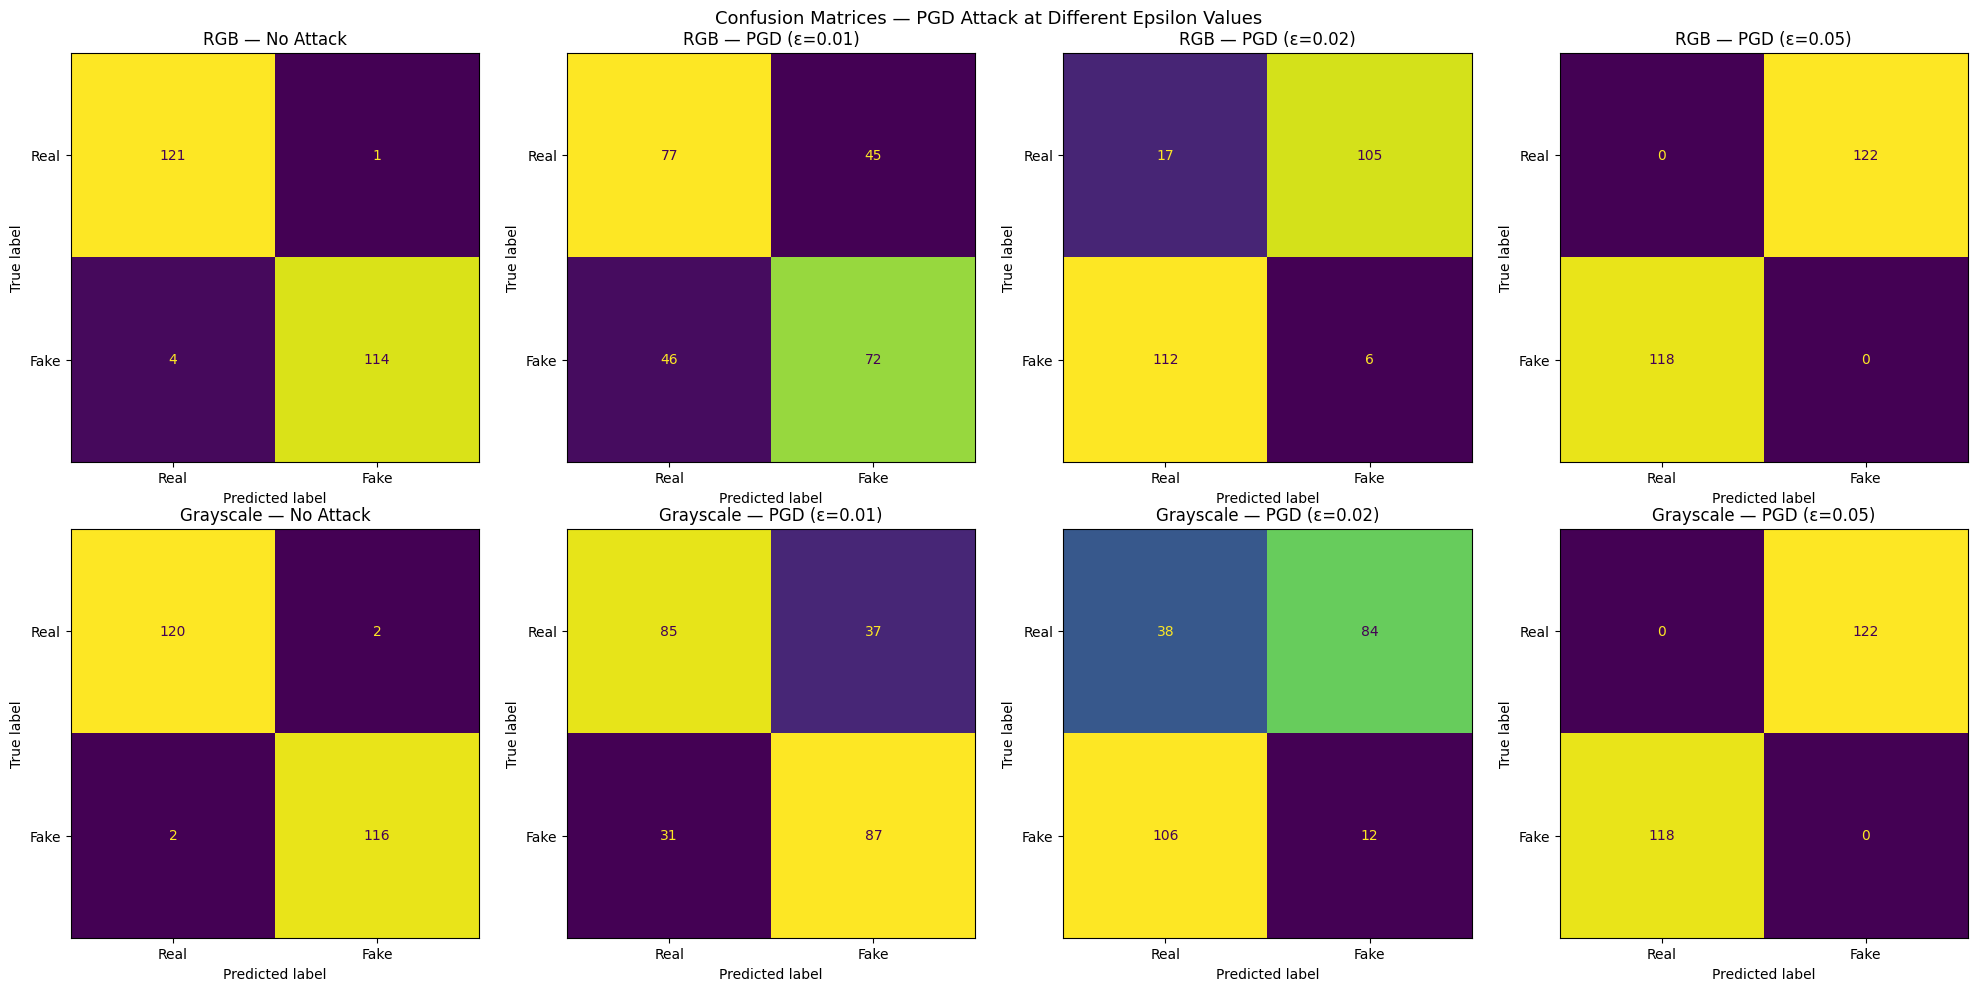

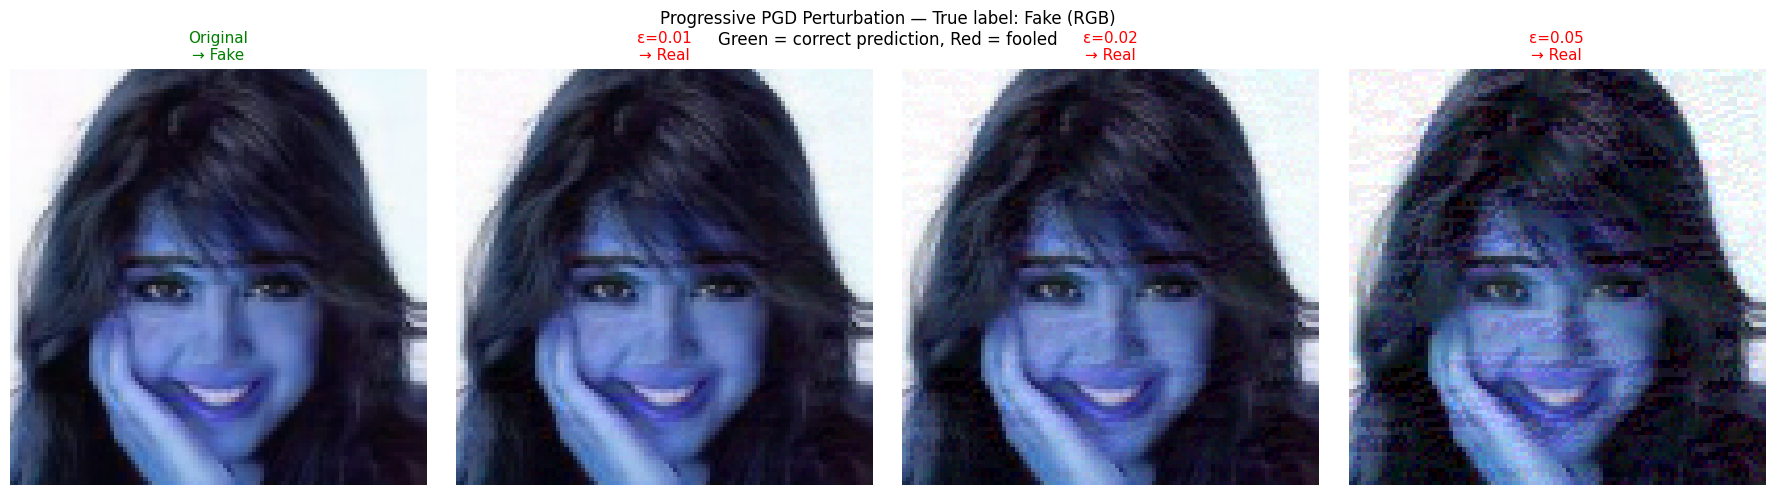

In [ ]:
# Confusion matrix visualization
epsilons_attack = [0.01, 0.02, 0.05]

# Clean predictions on original test set
y_pred_rgb_clean = np.argmax(model_rgb.predict(X_test, verbose=0), axis=1)
y_pred_gray_clean = np.argmax(model_gray.predict(X_test_gray, verbose=0), axis=1)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Column 0: no attack baseline
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rgb_clean),
                       display_labels=['Real','Fake']).plot(ax=axes[0,0], colorbar=False)
axes[0,0].set_title('RGB — No Attack')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gray_clean),
                       display_labels=['Real','Fake']).plot(ax=axes[1,0], colorbar=False)
axes[1,0].set_title('Grayscale — No Attack')

# Columns 1-3: use predictions
for col, eps in enumerate(epsilons_attack, start=1):
  y_pred_rgb_cm = preds_rgb[f'eps_{eps}']
  y_pred_gray_cm = preds_gray[f'eps_{eps}']

  ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rgb_cm),
                          display_labels=['Real','Fake']).plot(ax=axes[0,col], colorbar=False)
  axes[0,col].set_title(f'RGB — PGD (ε={eps})')

  ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gray_cm),
                          display_labels=['Real','Fake']).plot(ax=axes[1,col], colorbar=False)
  axes[1,col].set_title(f'Grayscale — PGD (ε={eps})')

plt.suptitle('Confusion Matrices — PGD Attack at Different Epsilon Values', fontsize=13)
plt.tight_layout()
plt.show()

# Search for a fake image correctly classified clean but already fooled at ε=0.01
candidate_idx = None
for idx in np.where(y_test == 1)[0]:
  img = X_test[idx:idx+1]
  lbl = y_test_c[idx:idx+1]

  # Skip if already misclassified without attack
  pred_clean = np.argmax(model_rgb.predict(img, verbose=0), axis=1)[0]
  if pred_clean != 1:
    continue

  # Check if fooled at ε=0.01
  adv_001 = pgd_attack(model_rgb, img, lbl, 0.01)
  pred_001 = np.argmax(model_rgb.predict(adv_001, verbose=0), axis=1)[0]

  if pred_001 != 1:
    candidate_idx = idx
    break

if candidate_idx is None:
  print("No image fooled at ε=0.01 — using first correctly classified fake.")
  for idx in np.where(y_test == 1)[0]:
    pred_clean = np.argmax(model_rgb.predict(X_test[idx:idx+1], verbose=0), axis=1)[0]
    if pred_clean == 1:
      candidate_idx = idx
      break

idx = candidate_idx
img_rgb = X_test[idx:idx+1]
lbl_rgb = y_test_c[idx:idx+1]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Column 0: original clean image
pred_clean = np.argmax(model_rgb.predict(img_rgb, verbose=0), axis=1)[0]
axes[0].imshow(np.clip(img_rgb[0], 0, 1))
axes[0].set_title(f'Original\n→ {label(pred_clean)}',
                  color='green' if pred_clean == y_test[idx] else 'red',
                  fontsize=11)
axes[0].axis('off')

# Columns 1-3: progressively perturbed images
for col, eps in enumerate(epsilons[1:], start=1):
  adv = pgd_attack(model_rgb, img_rgb, lbl_rgb, eps)
  pred = np.argmax(model_rgb.predict(adv, verbose=0), axis=1)[0]
  axes[col].imshow(np.clip(adv[0], 0, 1))
  axes[col].set_title(f'ε={eps}\n→ {label(pred)}',
                      color='green' if pred == y_test[idx] else 'red',
                      fontsize=11)
  axes[col].axis('off')

fig.suptitle(f'Progressive PGD Perturbation — True label: Fake (RGB)\n'
             f'Green = correct prediction, Red = fooled',
             fontsize=12)
plt.tight_layout()
plt.show()

## Results
| ε | RGB Accuracy | Grayscale Accuracy |
|---|---|---|
| 0.00 | 97.92% | 98.33% |
| 0.01 | 62.08% | 71.67% |
| 0.02 | 9.58% | 20.83% |
| 0.05 | 0.00% | 0.00% |

Both models collapse completely at ε=0.05 — visually perceptible but still contained perturbations entirely nullify the detection capability. Grayscale degrades more slowly, confirming its greater structural robustness.

## Confusion Matrices
The matrices clearly show how the attack pushes the model toward a systematic classification as "Real" — fakes are classified as real because the perturbation masks the structural artifacts the model had learned to recognize.

## Progressive Perturbation Visualization
The image shows a fake already fooled at ε=0.01 — the perturbation is visually imperceptible but sufficient to fool the model. A real attacker would choose the minimum ε necessary to evade the detector while keeping the image believable.

## STEP 2: Black-box Transfer Attack

In [ ]:
# ============================================================
# STEP 2 — TRANSFER ATTACK ON ORIGINAL MODELS
# The attacker has no knowledge of the target model.
# Adversarial examples are crafted on a surrogate model
# and transferred to the target model (Biggio et al., 2013;
# Papernot et al., 2016).
# Attack 1: surrogate=RGB → target=Grayscale
# Attack 2: surrogate=Grayscale → target=RGB
# ============================================================

print("="*60)
print("STEP 2 — TRANSFER ATTACK ON ORIGINAL MODELS")
print("="*60)

if os.path.exists('models/transfer_results.npz'):
  print("Transfer attack results found — loading from disk...")
  r = np.load('models/transfer_results.npz')
  epsilons = list(r['epsilons'])
  acc_transfer_gray = list(r['acc_bb_gray'])
  acc_transfer_rgb = list(r['acc_bb_rgb'])
  auc_transfer_gray = list(r['auc_bb_gray'])
  auc_transfer_rgb = list(r['auc_bb_rgb'])
  preds_transfer_gray = {
    'eps_0.0': r['pred_bb_gray_000'],
    'eps_0.01': r['pred_bb_gray_001'],
    'eps_0.02': r['pred_bb_gray_002'],
    'eps_0.05': r['pred_bb_gray_005']
  }
  preds_transfer_rgb = {
    'eps_0.0': r['pred_bb_rgb_000'],
    'eps_0.01': r['pred_bb_rgb_001'],
    'eps_0.02': r['pred_bb_rgb_002'],
    'eps_0.05': r['pred_bb_rgb_005']
  }
  for i, eps in enumerate(epsilons):
    print(f"ε={eps:.2f} | Transfer→Gray Acc: {acc_transfer_gray[i]*100:.2f}% | Transfer→RGB Acc: {acc_transfer_rgb[i]*100:.2f}%")

else:
  acc_transfer_gray = []
  acc_transfer_rgb = []
  auc_transfer_gray = []
  auc_transfer_rgb = []
  preds_transfer_gray = {}
  preds_transfer_rgb = {}

  for eps in epsilons:
    # Attack 1: surrogate=RGB → target=Grayscale
    X_adv_from_rgb = pgd_attack(model_rgb, X_test, y_test_c, eps)
    # Convert to grayscale for the target model
    X_adv_from_rgb_gray = np.mean(X_adv_from_rgb, axis=-1, keepdims=True)
    scores_transfer_gray = model_gray.predict(X_adv_from_rgb_gray, verbose=0)
    y_pred_transfer_gray = np.argmax(scores_transfer_gray, axis=1)
    acc_transfer_gray.append(accuracy_score(y_test, y_pred_transfer_gray))
    fpr_, tpr_, _ = roc_curve(y_test, scores_transfer_gray[:,1])
    auc_transfer_gray.append(auc(fpr_, tpr_))
    preds_transfer_gray[f'eps_{eps}'] = y_pred_transfer_gray

    # Attack 2: surrogate=Grayscale → target=RGB
    X_adv_from_gray = pgd_attack(model_gray, X_test_gray, y_test_c, eps)
    # Repeat grayscale channel to match RGB input shape
    X_adv_from_gray_rgb = np.repeat(X_adv_from_gray, 3, axis=-1)
    scores_transfer_rgb = model_rgb.predict(X_adv_from_gray_rgb, verbose=0)
    y_pred_transfer_rgb = np.argmax(scores_transfer_rgb, axis=1)
    acc_transfer_rgb.append(accuracy_score(y_test, y_pred_transfer_rgb))
    fpr_, tpr_, _ = roc_curve(y_test, scores_transfer_rgb[:,1])
    auc_transfer_rgb.append(auc(fpr_, tpr_))
    preds_transfer_rgb[f'eps_{eps}'] = y_pred_transfer_rgb

    print(f"ε={eps:.2f} | Transfer→Gray Acc: {acc_transfer_gray[-1]*100:.2f}% | Transfer→RGB Acc: {acc_transfer_rgb[-1]*100:.2f}%")

  np.savez('models/transfer_results.npz',
           epsilons=epsilons,
           acc_bb_gray=acc_transfer_gray,
           acc_bb_rgb=acc_transfer_rgb,
           auc_bb_gray=auc_transfer_gray,
           auc_bb_rgb=auc_transfer_rgb,
           pred_bb_gray_000=preds_transfer_gray['eps_0.0'],
           pred_bb_gray_001=preds_transfer_gray['eps_0.01'],
           pred_bb_gray_002=preds_transfer_gray['eps_0.02'],
           pred_bb_gray_005=preds_transfer_gray['eps_0.05'],
           pred_bb_rgb_000=preds_transfer_rgb['eps_0.0'],
           pred_bb_rgb_001=preds_transfer_rgb['eps_0.01'],
           pred_bb_rgb_002=preds_transfer_rgb['eps_0.02'],
           pred_bb_rgb_005=preds_transfer_rgb['eps_0.05'])
  print("Transfer attack results saved successfully.")

STEP 2 — TRANSFER ATTACK ON ORIGINAL MODELS
ε=0.00 | Transfer→Gray Acc: 98.33% | Transfer→RGB Acc: 97.08%
ε=0.01 | Transfer→Gray Acc: 91.67% | Transfer→RGB Acc: 87.08%
ε=0.02 | Transfer→Gray Acc: 80.42% | Transfer→RGB Acc: 64.17%
ε=0.05 | Transfer→Gray Acc: 19.58% | Transfer→RGB Acc: 2.92%
Transfer attack results saved successfully.


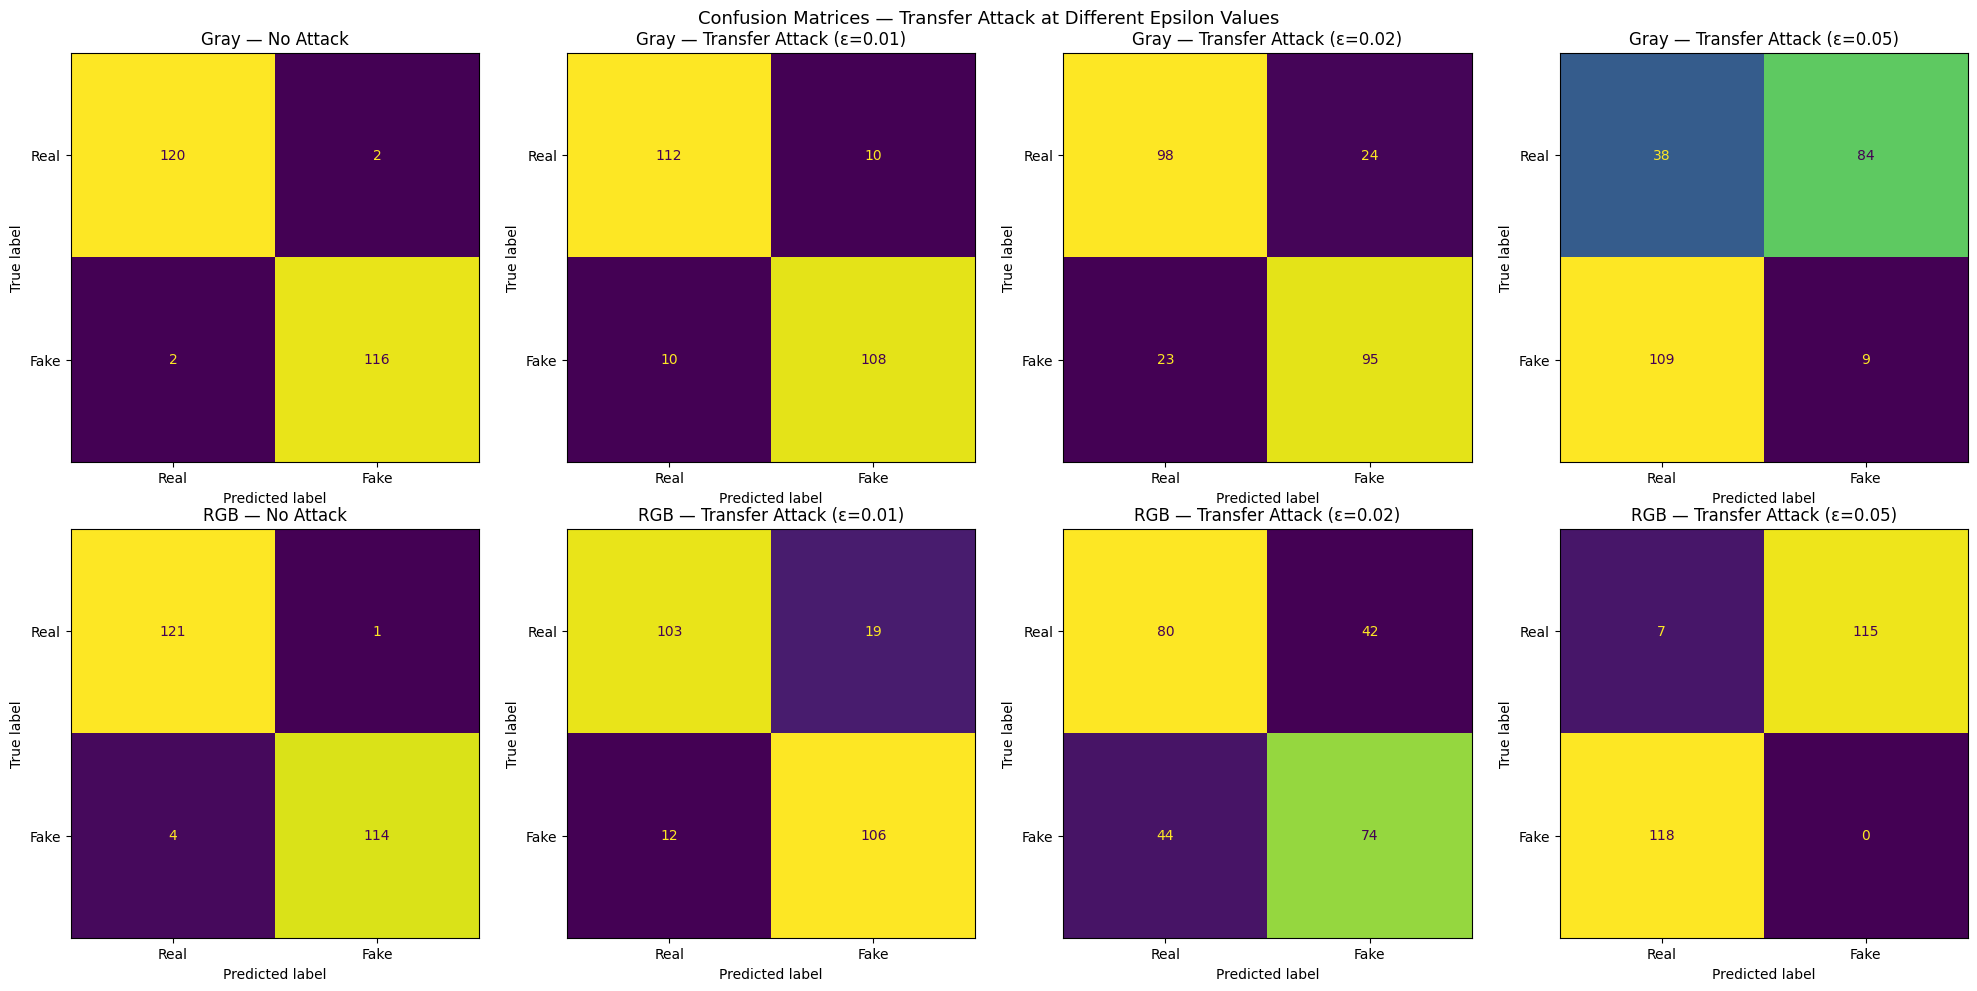

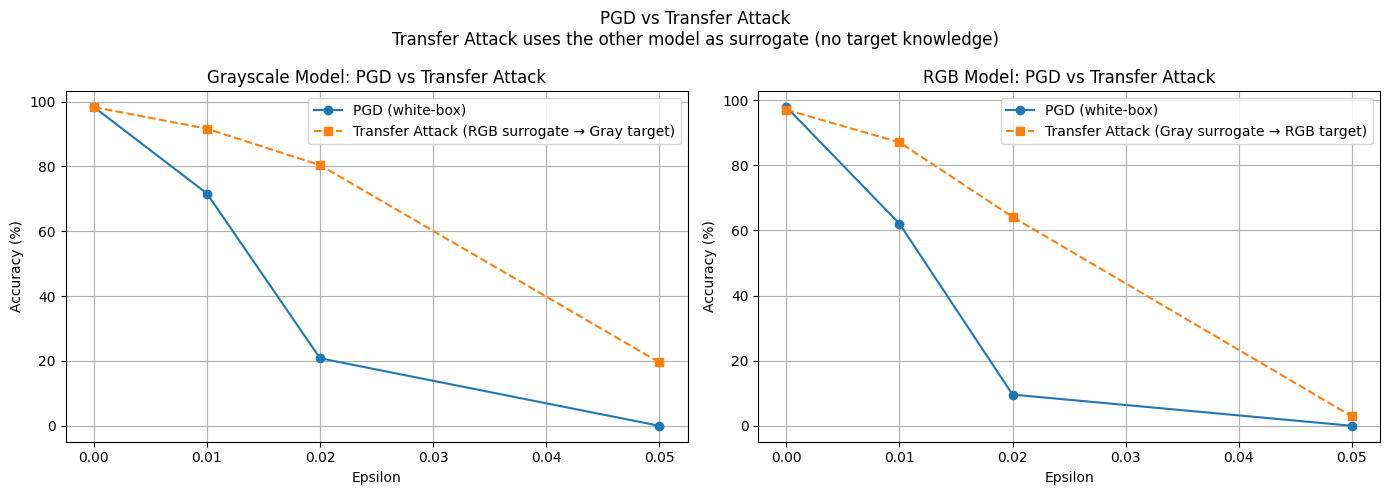

In [ ]:
# Confusion Matrices — Transfer Attack
y_pred_rgb_clean = np.argmax(model_rgb.predict(X_test, verbose=0), axis=1)
y_pred_gray_clean = np.argmax(model_gray.predict(X_test_gray, verbose=0), axis=1)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gray_clean),
                       display_labels=['Real','Fake']).plot(ax=axes[0,0], colorbar=False)
axes[0,0].set_title('Gray — No Attack')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rgb_clean),
                       display_labels=['Real','Fake']).plot(ax=axes[1,0], colorbar=False)
axes[1,0].set_title('RGB — No Attack')

for col, eps in enumerate([0.01, 0.02, 0.05], start=1):
  ConfusionMatrixDisplay(confusion_matrix(y_test, preds_transfer_gray[f'eps_{eps}']),
                          display_labels=['Real','Fake']).plot(ax=axes[0,col], colorbar=False)
  axes[0,col].set_title(f'Gray — Transfer Attack (ε={eps})')

  ConfusionMatrixDisplay(confusion_matrix(y_test, preds_transfer_rgb[f'eps_{eps}']),
                          display_labels=['Real','Fake']).plot(ax=axes[1,col], colorbar=False)
  axes[1,col].set_title(f'RGB — Transfer Attack (ε={eps})')

plt.suptitle('Confusion Matrices — Transfer Attack at Different Epsilon Values', fontsize=13)
plt.tight_layout()
plt.savefig('models/confusion_matrix_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

# PGD vs Transfer Attack accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epsilons, [a*100 for a in acc_gray_orig], marker='o', label='PGD (white-box)')
axes[0].plot(epsilons, [a*100 for a in acc_transfer_gray], marker='s', linestyle='--', label='Transfer Attack (RGB surrogate → Gray target)')
axes[0].set_title('Grayscale Model: PGD vs Transfer Attack')
axes[0].set_xlabel('Epsilon')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epsilons, [a*100 for a in acc_rgb_orig], marker='o', label='PGD (white-box)')
axes[1].plot(epsilons, [a*100 for a in acc_transfer_rgb], marker='s', linestyle='--', label='Transfer Attack (Gray surrogate → RGB target)')
axes[1].set_title('RGB Model: PGD vs Transfer Attack')
axes[1].set_xlabel('Epsilon')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('PGD vs Transfer Attack\nTransfer Attack uses the other model as surrogate (no target knowledge)', fontsize=12)
plt.tight_layout()
plt.savefig('models/pgd_vs_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

The transfer attack exploits the **transferability** of adversarial examples (Biggio et al., 2013; Papernot et al., 2016): perturbations generated on a surrogate model partially transfer to the target model, even without access to its gradients.

## Configuration
- **Attack 1**: surrogate RGB → target Grayscale
- **Attack 2**: surrogate Grayscale → target RGB

## Results
| ε | Transfer→Gray Acc | Transfer→RGB Acc |
|---|---|---|
| 0.00 | 98.33% | 97.08% |
| 0.01 | 91.67% | 87.08% |
| 0.02 | 79.58% | 64.17% |
| 0.05 | 19.58% | 2.92% |

## Observations
The Transfer Attack degrades more slowly than PGD — at ε=0.01 Grayscale holds 91.67% versus 71.67% under PGD. This was expected: without access to the target's gradients, the perturbations are less optimized.

However, the attack remains **significant**: at ε=0.05 both models collapse even in the black-box setting, confirming that transferability is sufficient to compromise the detector even in realistic scenarios where the attacker does not know the victim model.

Grayscale also proves more robust under black-box attack — its lower sensitivity to chromatic perturbations makes it less vulnerable to perturbations generated on an RGB model with a different feature space.

## STEP 3: Adversarial Training

In [ ]:
# ============================================================
# STEP 3 — ADVERSARIAL TRAINING (Madry et al., 2018)
# Implements: min_theta E[max_delta L(x+delta, y, theta)]
# At each batch: generate PGD adversarial examples (inner
# maximization), then update weights minimizing a combined
# loss of natural + adversarial examples (outer minimization).
# Combined loss: (1-alpha)*L_natural + alpha*L_adversarial
# following the lab formulation (alpha=0.5).
# ============================================================

def adversarial_training(model, X_train, y_train_c, X_val, y_val_c,
                         epsilon=0.01, alpha_pgd=0.005, pgd_steps=10,
                         alpha_loss=0.5, epochs=50, batch_size=4, patience=15):
  """
  Adversarial training with combined natural + adversarial loss.
  alpha_loss controls the trade-off between natural and robust accuracy.
  Early stopping monitors adversarial validation loss.
  """
  adv_model = tf.keras.models.clone_model(model)
  adv_model.set_weights(model.get_weights())
  adv_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='mse')

  best_weights = adv_model.get_weights()
  best_val_loss = np.inf
  patience_counter = 0

  n_samples = len(X_train)
  indices = np.arange(n_samples)

  for epoch in range(epochs):
    np.random.shuffle(indices)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, n_samples, batch_size):
      batch_idx = indices[start:start+batch_size]
      X_batch = X_train[batch_idx]
      y_batch = y_train_c[batch_idx]

      # Inner maximization: generate PGD adversarial examples
      X_adv_batch = pgd_attack(adv_model, X_batch, y_batch,
                              epsilon=epsilon, alpha=alpha_pgd, steps=pgd_steps)

      # Outer minimization: combined natural + adversarial loss
      # L = (1-alpha)*L_natural + alpha*L_adversarial
      loss_nat = adv_model.train_on_batch(X_batch,     y_batch)
      loss_adv = adv_model.train_on_batch(X_adv_batch, y_batch)
      loss_nat = loss_nat[0] if isinstance(loss_nat, list) else loss_nat
      loss_adv = loss_adv[0] if isinstance(loss_adv, list) else loss_adv
      epoch_loss += (1 - alpha_loss) * loss_nat + alpha_loss * loss_adv
      n_batches += 1

    # Validation on adversarial examples — monitors worst-case loss
    X_val_adv = pgd_attack(adv_model, X_val, y_val_c,
                          epsilon=epsilon, alpha=alpha_pgd, steps=pgd_steps)
    val_loss = adv_model.evaluate(X_val_adv, y_val_c, verbose=0)
    val_loss = val_loss[0] if isinstance(val_loss, list) else val_loss

    train_acc = np.mean(np.argmax(adv_model.predict(X_train[indices[:len(indices)]], verbose=0), axis=1) == np.argmax(y_train_c[indices[:len(indices)]], axis=1))
    val_acc = np.mean(np.argmax(adv_model.predict(X_val_adv, verbose=0), axis=1) == np.argmax(y_val_c, axis=1))
    print(f"Epoch {epoch+1}/{epochs} — accuracy: {train_acc*100:.2f}%  - loss: {epoch_loss/n_batches:.4f} - val accuracy: {val_acc*100:.2f}% - val loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      best_weights = adv_model.get_weights()
      patience_counter = 0
    else:
      patience_counter += 1
      if patience_counter >= patience:
        print(f"  Early stopping at epoch {epoch+1} (patience={patience})")
        break

  adv_model.set_weights(best_weights)
  return adv_model

if os.path.exists('models/model_rgb_adv.keras') and os.path.exists('models/model_gray_adv.keras'):
  print("Adversarial models found — loading from disk...")
  model_rgb_adv  = tf.keras.models.load_model('models/model_rgb_adv.keras')
  model_gray_adv = tf.keras.models.load_model('models/model_gray_adv.keras')
  print("Adversarial models loaded successfully.")
else:
  print("No adversarial models found — training from scratch...")

  print("="*60)
  print("STEP 3 — ADVERSARIAL TRAINING")
  print("="*60)

  print("="*60)
  print("RGB — ε=0.01")
  print("="*60)
  model_rgb_adv = adversarial_training(
    model_rgb, X_train, y_train_c, X_val, y_val_c,
    epsilon=0.01, alpha_pgd=0.005, pgd_steps=10,
    alpha_loss=0.5, epochs=50, batch_size=4, patience=15)

  print("="*60)
  print("Grayscale — ε=0.01")
  print("="*60)
  model_gray_adv = adversarial_training(
    model_gray, X_train_gray, y_train_c, X_val_gray, y_val_c,
    epsilon=0.01, alpha_pgd=0.005, pgd_steps=10,
    alpha_loss=0.5, epochs=50, batch_size=4, patience=15)

  model_rgb_adv.save('models/model_rgb_adv.keras')
  model_gray_adv.save('models/model_gray_adv.keras')
  print("Adversarial models saved.")

  print("\n" + "="*60)
  print("EVALUATION ON CLEAN TEST SET — ADVERSARIALLY TRAINED MODELS")
  print("="*60)
  loss_rgb_adv,  acc_rgb_adv_clean  = model_rgb_adv.evaluate(X_test,       y_test_c, verbose=0)
  loss_gray_adv, acc_gray_adv_clean = model_gray_adv.evaluate(X_test_gray, y_test_c, verbose=0)
  print(f"RGB Adv. Trained   - Loss: {loss_rgb_adv:.4f} | Accuracy: {acc_rgb_adv_clean*100:.2f}%")
  print(f"Gray Adv. Trained  - Loss: {loss_gray_adv:.4f} | Accuracy: {acc_gray_adv_clean*100:.2f}%")

No adversarial models found — training from scratch...
STEP 3 — ADVERSARIAL TRAINING
RGB — ε=0.01
Epoch 1/50 — accuracy: 100.00%  - loss: 0.0778 - val accuracy: 72.08% - val loss: 0.2157
Epoch 2/50 — accuracy: 99.86%  - loss: 0.1069 - val accuracy: 74.58% - val loss: 0.1807
Epoch 3/50 — accuracy: 99.86%  - loss: 0.0831 - val accuracy: 76.25% - val loss: 0.1667
Epoch 4/50 — accuracy: 100.00%  - loss: 0.0783 - val accuracy: 80.00% - val loss: 0.1601
Epoch 5/50 — accuracy: 100.00%  - loss: 0.0725 - val accuracy: 80.83% - val loss: 0.1512
Epoch 6/50 — accuracy: 100.00%  - loss: 0.0707 - val accuracy: 80.83% - val loss: 0.1487
Epoch 7/50 — accuracy: 100.00%  - loss: 0.0644 - val accuracy: 82.08% - val loss: 0.1451
Epoch 8/50 — accuracy: 100.00%  - loss: 0.0614 - val accuracy: 80.00% - val loss: 0.1540
Epoch 9/50 — accuracy: 100.00%  - loss: 0.0640 - val accuracy: 80.83% - val loss: 0.1455
Epoch 10/50 — accuracy: 100.00%  - loss: 0.0599 - val accuracy: 84.17% - val loss: 0.1333
Epoch 11/50 —

Adversarial training (Madry et al., 2018) implements the min-max formulation:
**min_θ E[max_δ L(x+δ, y; θ)]** — at each batch it generates adversarial examples with PGD (inner maximization) and updates the weights by minimizing a combined loss (outer minimization):

**L = (1 - α) · L_natural + α · L_adversarial**, with α = 0.5

Validation loss is monitored on adversarial examples, consistent with the min-max formulation.

| Model | Training ε | Final epoch | Best val loss |
|-------|------------|-------------|---------------|
| RGB | 0.01 | 50 | 0.1071 |
| Grayscale | 0.01 | 50 | 0.1232 |

The val loss is significantly higher than the original model (~0.02) — expected, since the task is harder: the model must correctly classify both clean and perturbed examples. Both models reached the 50-epoch limit without patience expiring, indicating that training was still slowly improving.

## STEP 4: PGD and Transfer Attack on Adversarially Trained Models

STEP 4 — PGD ON ADVERSARIALLY TRAINED MODELS
ε=0.00 | RGB Adv PGD Acc: 99.17% | Gray Adv PGD Acc: 97.92%
ε=0.01 | RGB Adv PGD Acc: 87.92% | Gray Adv PGD Acc: 85.42%
ε=0.02 | RGB Adv PGD Acc: 41.25% | Gray Adv PGD Acc: 47.08%
ε=0.05 | RGB Adv PGD Acc: 0.83% | Gray Adv PGD Acc: 0.83%
STEP 4 — TRANSFER ATTACK ON ADVERSARIALLY TRAINED MODELS
ε=0.00 | Transfer→Gray Adv Acc: 97.92% | Transfer→RGB Adv Acc: 98.75%
ε=0.01 | Transfer→Gray Adv Acc: 93.33% | Transfer→RGB Adv Acc: 96.67%
ε=0.02 | Transfer→Gray Adv Acc: 90.00% | Transfer→RGB Adv Acc: 86.25%
ε=0.05 | Transfer→Gray Adv Acc: 39.17% | Transfer→RGB Adv Acc: 19.58%


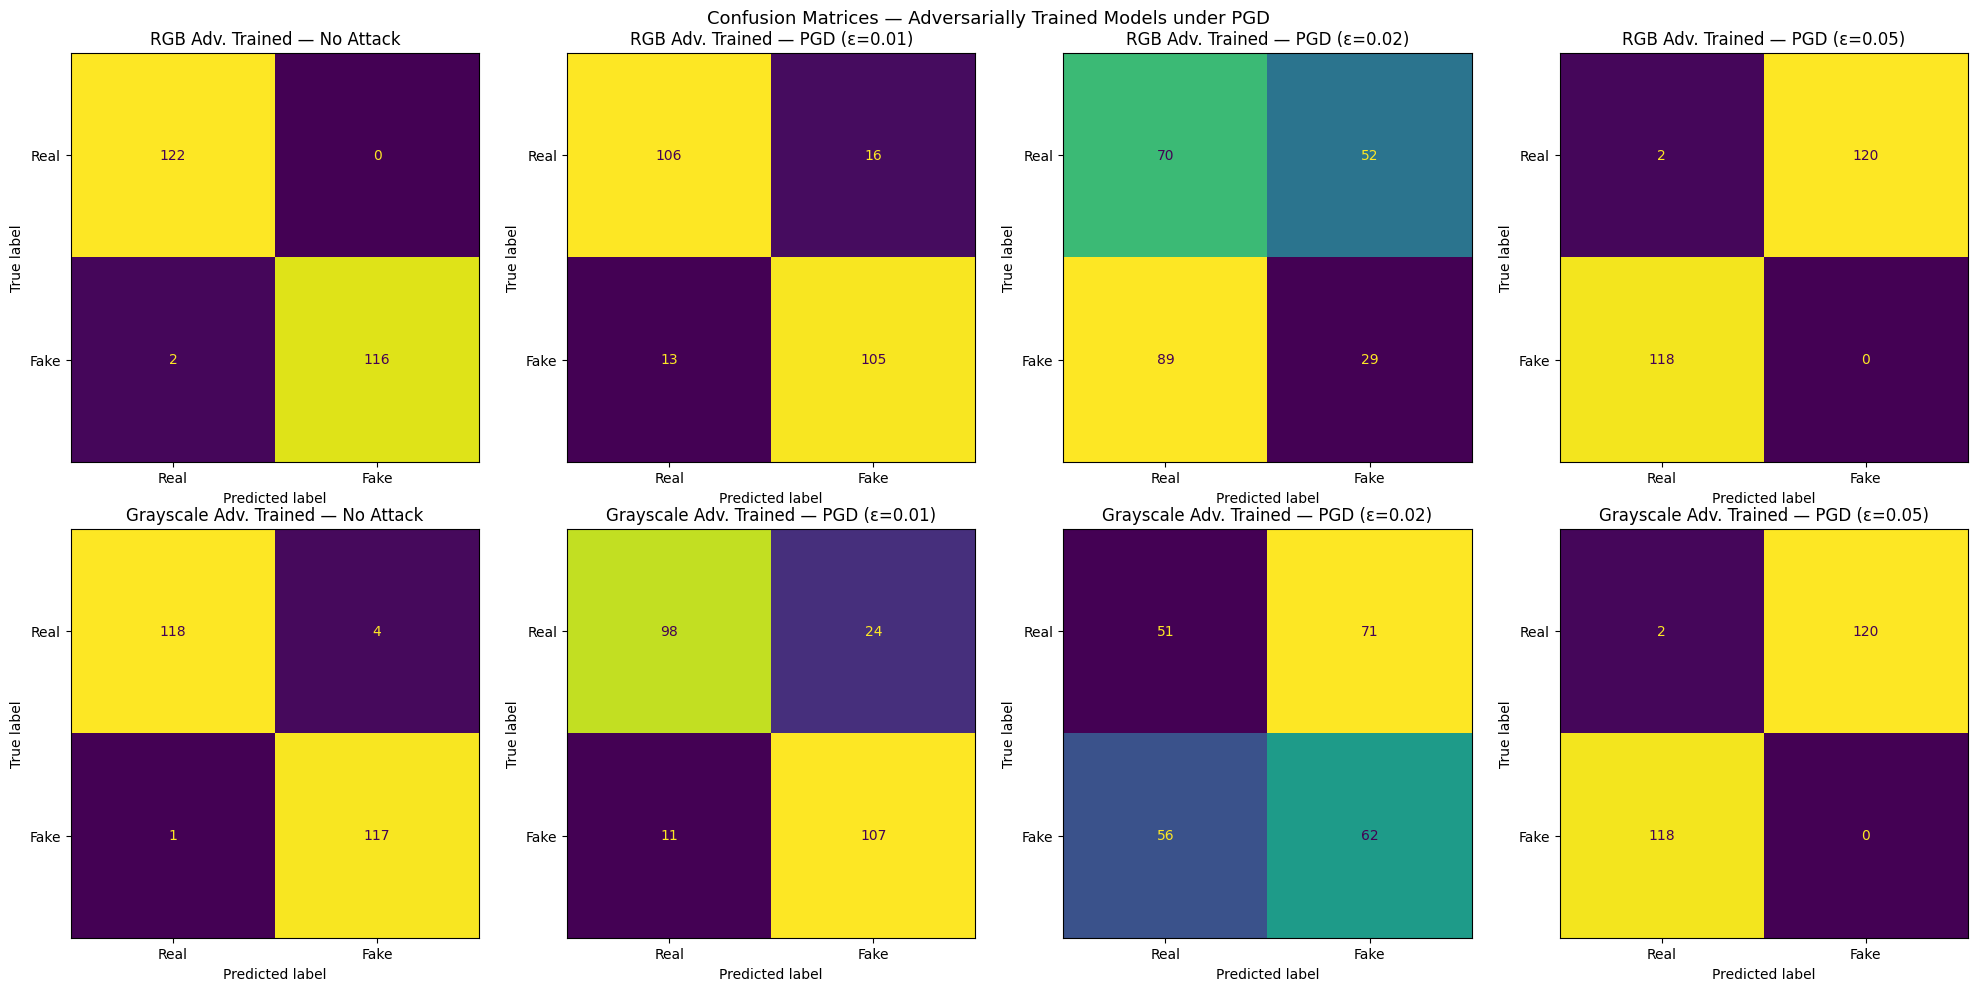

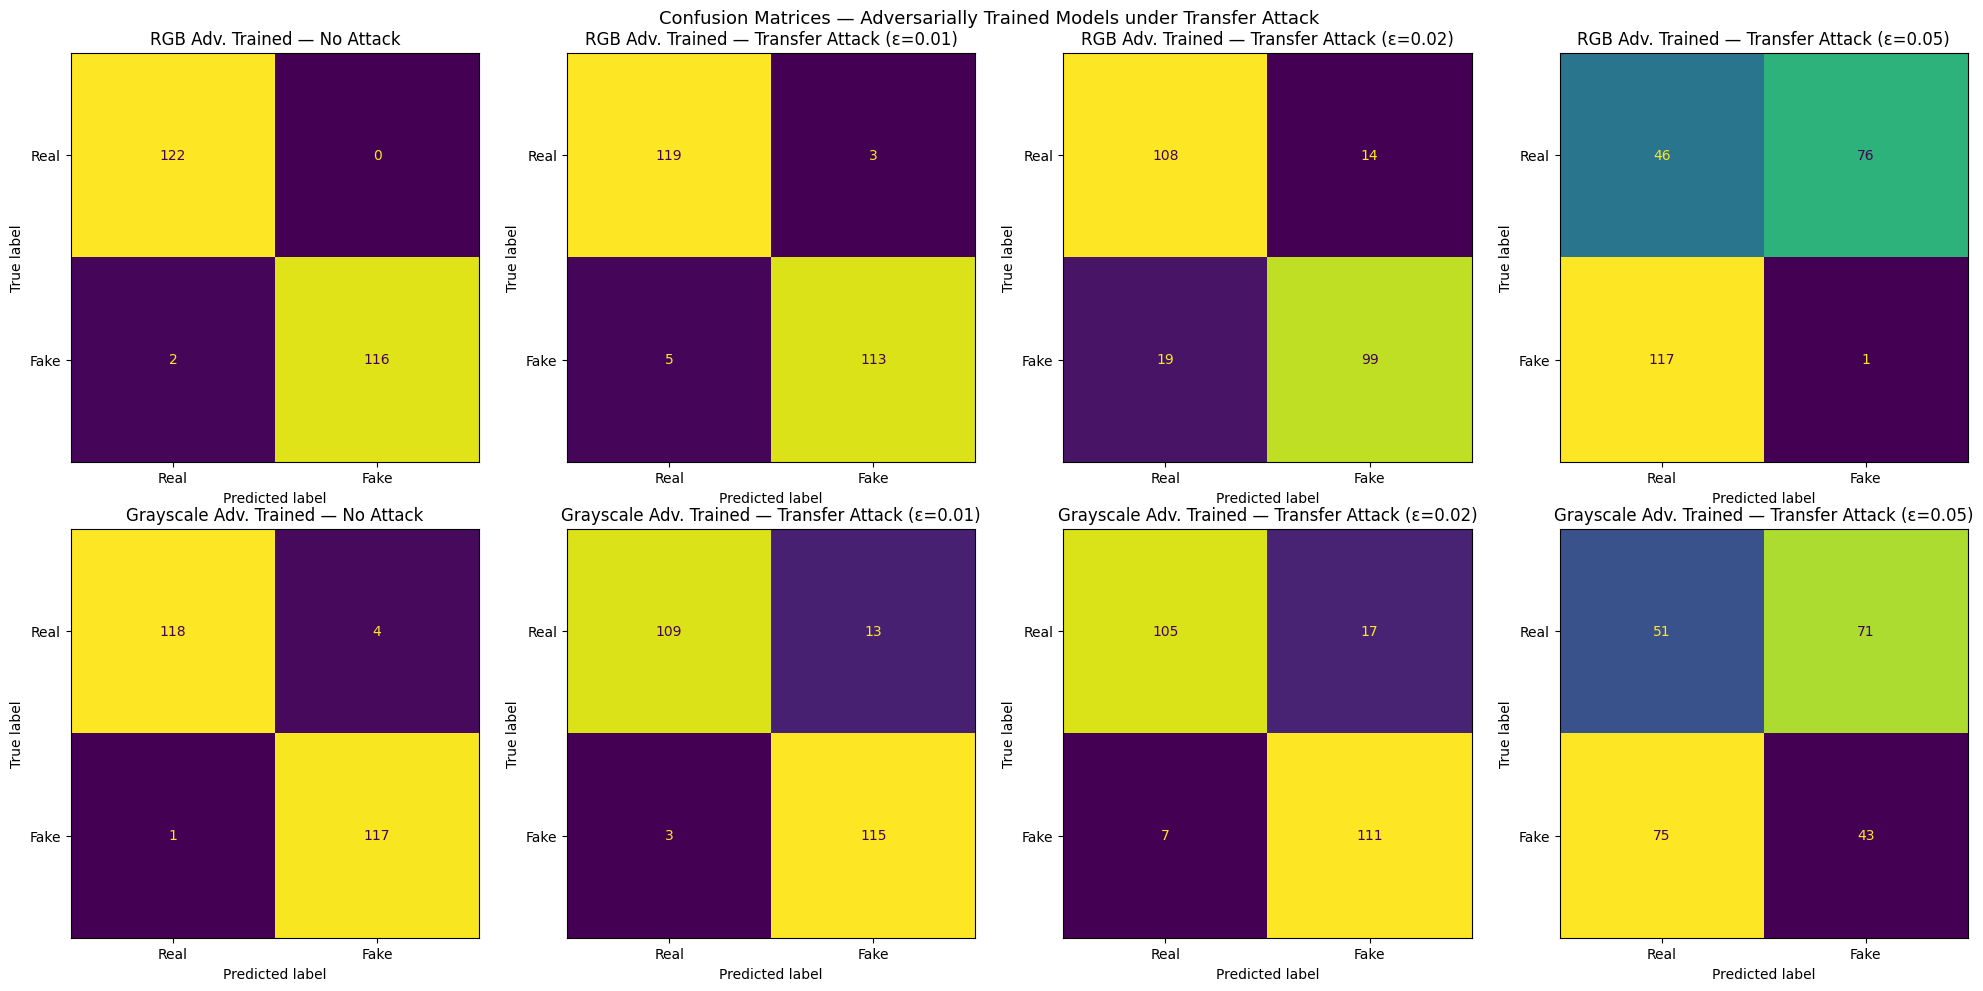

Results saved successfully.


In [ ]:
# ============================================================
# STEP 4 — PGD AND TRANSFER ATTACK ON ADVERSARIALLY
# TRAINED MODELS
# Evaluates robust accuracy of defended models under both
# PGD (full gradient access) and Transfer Attack (no target
# knowledge) scenarios.
# ============================================================

acc_rgb_adv_pgd      = []
acc_gray_adv_pgd     = []
auc_rgb_adv_pgd      = []
auc_gray_adv_pgd     = []

acc_transfer_gray_adv = []
acc_transfer_rgb_adv  = []
auc_transfer_gray_adv = []
auc_transfer_rgb_adv  = []

preds_rgb_adv_pgd      = {}
preds_gray_adv_pgd     = {}
preds_transfer_gray_adv = {}
preds_transfer_rgb_adv  = {}

print("="*60)
print("STEP 4 — PGD ON ADVERSARIALLY TRAINED MODELS")
print("="*60)

for eps in epsilons:
  X_adv_rgb_pgd = pgd_attack(model_rgb_adv, X_test, y_test_c, eps)
  X_adv_gray_pgd = pgd_attack(model_gray_adv, X_test_gray, y_test_c, eps)

  scores_rgb_pgd = model_rgb_adv.predict(X_adv_rgb_pgd,   verbose=0)
  scores_gray_pgd = model_gray_adv.predict(X_adv_gray_pgd, verbose=0)

  y_pred_rgb_pgd = np.argmax(scores_rgb_pgd,  axis=1)
  y_pred_gray_pgd = np.argmax(scores_gray_pgd, axis=1)

  acc_rgb_adv_pgd.append(accuracy_score(y_test, y_pred_rgb_pgd))
  acc_gray_adv_pgd.append(accuracy_score(y_test, y_pred_gray_pgd))

  fpr_r, tpr_r, _ = roc_curve(y_test, scores_rgb_pgd[:,1])
  fpr_g, tpr_g, _ = roc_curve(y_test, scores_gray_pgd[:,1])
  auc_rgb_adv_pgd.append(auc(fpr_r, tpr_r))
  auc_gray_adv_pgd.append(auc(fpr_g, tpr_g))

  preds_rgb_adv_pgd[f'eps_{eps}'] = y_pred_rgb_pgd
  preds_gray_adv_pgd[f'eps_{eps}'] = y_pred_gray_pgd

  print(f"ε={eps:.2f} | RGB Adv PGD Acc: {acc_rgb_adv_pgd[-1]*100:.2f}% | Gray Adv PGD Acc: {acc_gray_adv_pgd[-1]*100:.2f}%")

print("="*60)
print("STEP 4 — TRANSFER ATTACK ON ADVERSARIALLY TRAINED MODELS")
print("="*60)

for eps in epsilons:
  # Attack 1: surrogate=RGB original → target=Gray adv. trained
  X_adv_from_rgb = pgd_attack(model_rgb, X_test, y_test_c, eps)
  # Convert to grayscale for the target model
  X_adv_from_rgb_gray = np.mean(X_adv_from_rgb, axis=-1, keepdims=True)
  scores_transfer_gray = model_gray_adv.predict(X_adv_from_rgb_gray, verbose=0)
  y_pred_transfer_gray = np.argmax(scores_transfer_gray, axis=1)
  acc_transfer_gray_adv.append(accuracy_score(y_test, y_pred_transfer_gray))
  fpr_, tpr_, _ = roc_curve(y_test, scores_transfer_gray[:,1])
  auc_transfer_gray_adv.append(auc(fpr_, tpr_))
  preds_transfer_gray_adv[f'eps_{eps}'] = y_pred_transfer_gray

  # Attack 2: surrogate=Gray original → target=RGB adv. trained
  X_adv_from_gray = pgd_attack(model_gray, X_test_gray, y_test_c, eps)
  # Repeat grayscale channel to match RGB input shape
  X_adv_from_gray_rgb = np.repeat(X_adv_from_gray, 3, axis=-1)
  scores_transfer_rgb = model_rgb_adv.predict(X_adv_from_gray_rgb, verbose=0)
  y_pred_transfer_rgb = np.argmax(scores_transfer_rgb, axis=1)
  acc_transfer_rgb_adv.append(accuracy_score(y_test, y_pred_transfer_rgb))
  fpr_, tpr_, _ = roc_curve(y_test, scores_transfer_rgb[:,1])
  auc_transfer_rgb_adv.append(auc(fpr_, tpr_))
  preds_transfer_rgb_adv[f'eps_{eps}'] = y_pred_transfer_rgb

  print(f"ε={eps:.2f} | Transfer→Gray Adv Acc: {acc_transfer_gray_adv[-1]*100:.2f}% | Transfer→RGB Adv Acc: {acc_transfer_rgb_adv[-1]*100:.2f}%")

# Confusion Matrices — PGD on Adv. Trained Models
y_pred_rgb_adv_clean  = np.argmax(model_rgb_adv.predict(X_test, verbose=0), axis=1)
y_pred_gray_adv_clean = np.argmax(model_gray_adv.predict(X_test_gray, verbose=0), axis=1)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rgb_adv_clean),
                       display_labels=['Real','Fake']).plot(ax=axes[0,0], colorbar=False)
axes[0,0].set_title('RGB Adv. Trained — No Attack')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gray_adv_clean),
                       display_labels=['Real','Fake']).plot(ax=axes[1,0], colorbar=False)
axes[1,0].set_title('Grayscale Adv. Trained — No Attack')

for col, eps in enumerate([0.01, 0.02, 0.05], start=1):
  ConfusionMatrixDisplay(confusion_matrix(y_test, preds_rgb_adv_pgd[f'eps_{eps}']),
                          display_labels=['Real','Fake']).plot(ax=axes[0,col], colorbar=False)
  axes[0,col].set_title(f'RGB Adv. Trained — PGD (ε={eps})')

  ConfusionMatrixDisplay(confusion_matrix(y_test, preds_gray_adv_pgd[f'eps_{eps}']),
                          display_labels=['Real','Fake']).plot(ax=axes[1,col], colorbar=False)
  axes[1,col].set_title(f'Grayscale Adv. Trained — PGD (ε={eps})')

plt.suptitle('Confusion Matrices — Adversarially Trained Models under PGD', fontsize=13)
plt.tight_layout()
plt.show()

# Confusion Matrices — Transfer Attack on Adv. Trained Models
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rgb_adv_clean),
                       display_labels=['Real','Fake']).plot(ax=axes[0,0], colorbar=False)
axes[0,0].set_title('RGB Adv. Trained — No Attack')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gray_adv_clean),
                       display_labels=['Real','Fake']).plot(ax=axes[1,0], colorbar=False)
axes[1,0].set_title('Grayscale Adv. Trained — No Attack')

for col, eps in enumerate([0.01, 0.02, 0.05], start=1):
  ConfusionMatrixDisplay(confusion_matrix(y_test, preds_transfer_rgb_adv[f'eps_{eps}']),
                          display_labels=['Real','Fake']).plot(ax=axes[0,col], colorbar=False)
  axes[0,col].set_title(f'RGB Adv. Trained — Transfer Attack (ε={eps})')

  ConfusionMatrixDisplay(confusion_matrix(y_test, preds_transfer_gray_adv[f'eps_{eps}']),
                          display_labels=['Real','Fake']).plot(ax=axes[1,col], colorbar=False)
  axes[1,col].set_title(f'Grayscale Adv. Trained — Transfer Attack (ε={eps})')

plt.suptitle('Confusion Matrices — Adversarially Trained Models under Transfer Attack', fontsize=13)
plt.tight_layout()
plt.show()

# Save all results
np.savez('models/adv_training_results.npz',
         epsilons=epsilons,
         acc_rgb_adv_pgd=acc_rgb_adv_pgd,
         acc_gray_adv_pgd=acc_gray_adv_pgd,
         auc_rgb_adv_pgd=auc_rgb_adv_pgd,
         auc_gray_adv_pgd=auc_gray_adv_pgd,
         acc_transfer_gray_adv=acc_transfer_gray_adv,
         acc_transfer_rgb_adv=acc_transfer_rgb_adv,
         auc_transfer_gray_adv=auc_transfer_gray_adv,
         auc_transfer_rgb_adv=auc_transfer_rgb_adv)
print("Results saved successfully.")

After adversarial training, both models are re-evaluated under attack to measure the robustness improvement.

**PGD (white-box) on defended models:**

| ε | RGB Adv. Trained | Grayscale Adv. Trained |
|---|---|---|
| 0.00 | 99.17% | 97.92% |
| 0.01 | 87.92% | 85.42% |
| 0.02 | 41.25% | 47.08% |
| 0.05 | 0.83% | 0.83% |

**Transfer Attack (black-box) on defended models:**

| ε | →Gray Adv. | →RGB Adv. |
|---|---|---|
| 0.00 | 97.92% | 98.75% |
| 0.01 | 93.33% | 96.67% |
| 0.02 | 90.00% | 86.25% |
| 0.05 | 39.17% | 19.58% |

Adversarial training significantly improves robustness at ε=0.01 and ε=0.02. At ε=0.05 both models still collapse — the defense is effective within the ε range used in training (0.01), but does not generalize to larger perturbations.

## STEP 5 — Final Comparison

STEP 5 — FINAL SUMMARY

RGB Model:
  Clean Acc (original):           97.92%
  Clean Acc (adv. trained):        99.17%
  PGD Robust Acc (ε=0.01) — Original: 62.08% | Adv Trained: 87.92%
  PGD Robust Acc (ε=0.02) — Original: 9.58% | Adv Trained: 41.25%
  PGD Robust Acc (ε=0.05) — Original: 0.00% | Adv Trained: 0.83%
  Transfer Robust Acc (ε=0.01) — Original: 87.08% | Adv Trained: 96.67%
  Transfer Robust Acc (ε=0.02) — Original: 64.17% | Adv Trained: 86.25%
  Transfer Robust Acc (ε=0.05) — Original: 2.92% | Adv Trained: 19.58%

Grayscale Model:
  Clean Acc (original):           98.33%
  Clean Acc (adv. trained):        97.92%
  PGD Robust Acc (ε=0.01) — Original: 71.67% | Adv Trained: 85.42%
  PGD Robust Acc (ε=0.02) — Original: 20.83% | Adv Trained: 47.08%
  PGD Robust Acc (ε=0.05) — Original: 0.00% | Adv Trained: 0.83%
  Transfer Robust Acc (ε=0.01) — Original: 91.67% | Adv Trained: 93.33%
  Transfer Robust Acc (ε=0.02) — Original: 80.42% | Adv Trained: 90.00%
  Transfer Robust Acc (ε=

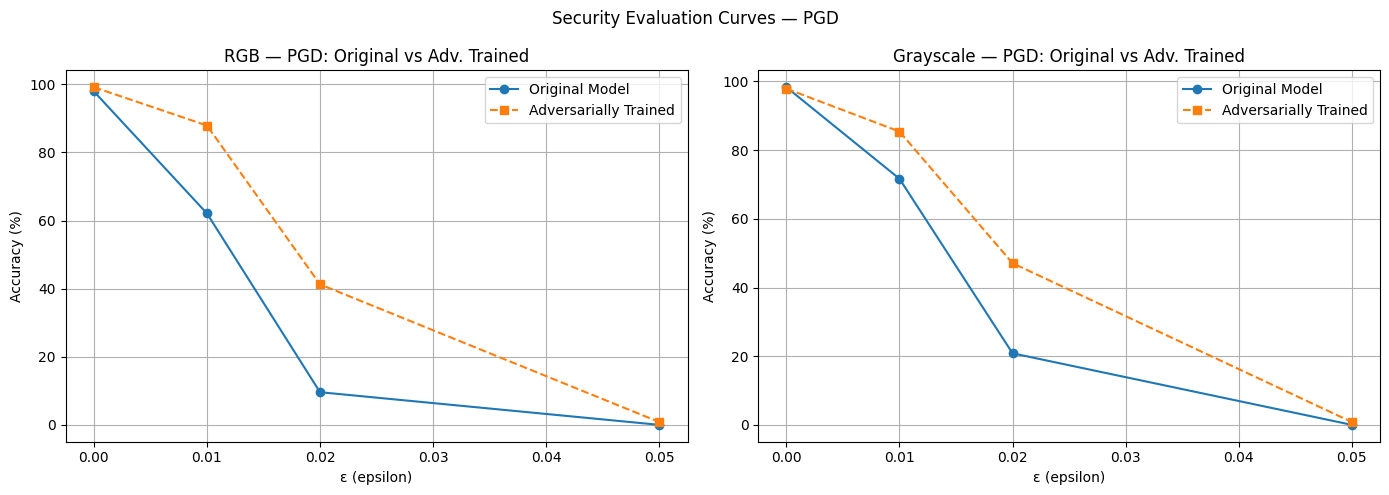

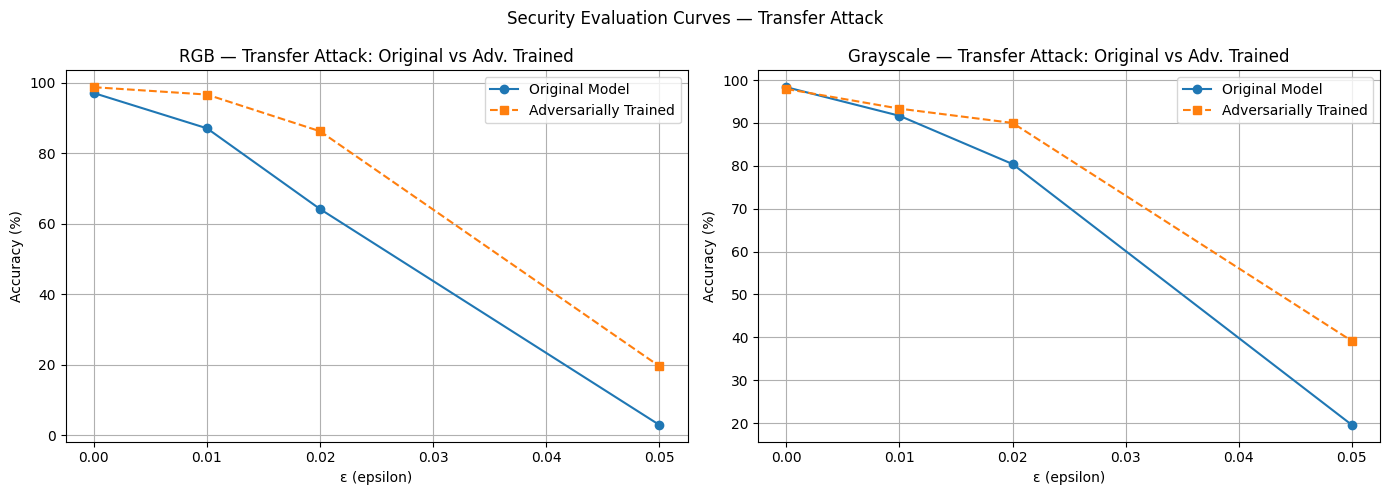

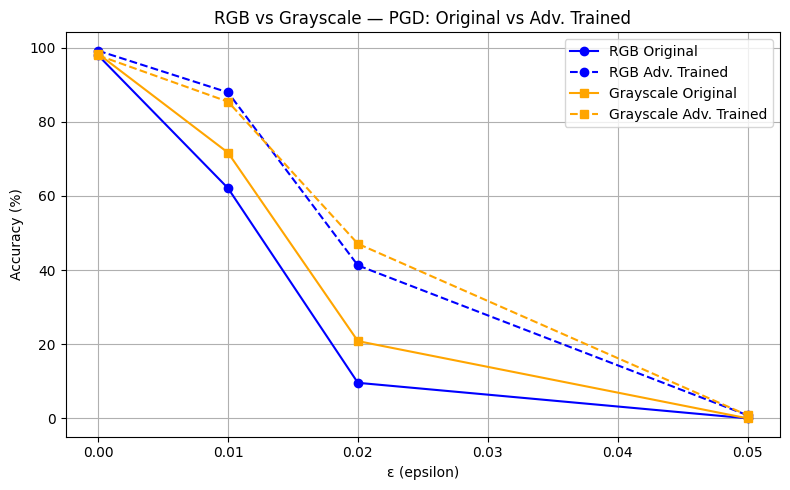

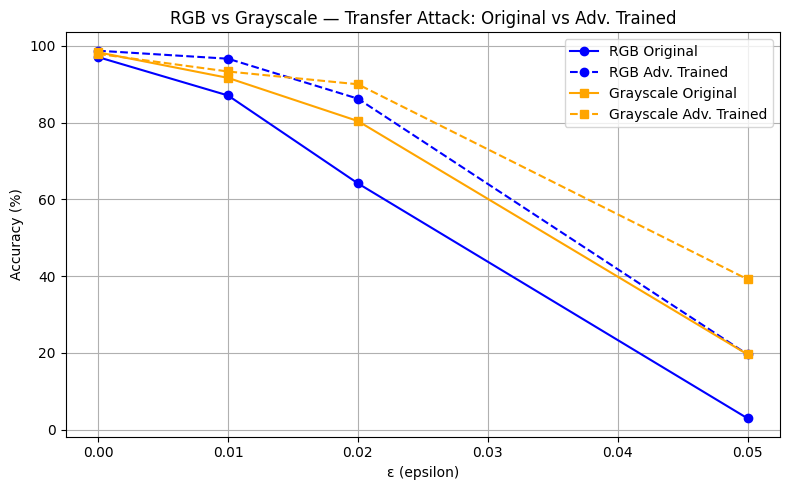

In [ ]:
# ============================================================
# STEP 5 — FINAL COMPARISON
# Clean accuracy vs robust accuracy
# PGD vs Transfer Attack
# Original vs adversarially trained
# RGB vs Grayscale
# ============================================================

idx_001 = epsilons.index(0.01)
idx_002 = epsilons.index(0.02)
idx_005 = epsilons.index(0.05)

print("="*60)
print("STEP 5 — FINAL SUMMARY")
print("="*60)
print(f"\nRGB Model:")
print(f"  Clean Acc (original):           {acc_rgb_orig[0]*100:.2f}%")
print(f"  Clean Acc (adv. trained):        {acc_rgb_adv_pgd[0]*100:.2f}%")
print(f"  PGD Robust Acc (ε=0.01) — Original: {acc_rgb_orig[idx_001]*100:.2f}% | Adv Trained: {acc_rgb_adv_pgd[idx_001]*100:.2f}%")
print(f"  PGD Robust Acc (ε=0.02) — Original: {acc_rgb_orig[idx_002]*100:.2f}% | Adv Trained: {acc_rgb_adv_pgd[idx_002]*100:.2f}%")
print(f"  PGD Robust Acc (ε=0.05) — Original: {acc_rgb_orig[idx_005]*100:.2f}% | Adv Trained: {acc_rgb_adv_pgd[idx_005]*100:.2f}%")
print(f"  Transfer Robust Acc (ε=0.01) — Original: {acc_transfer_rgb[idx_001]*100:.2f}% | Adv Trained: {acc_transfer_rgb_adv[idx_001]*100:.2f}%")
print(f"  Transfer Robust Acc (ε=0.02) — Original: {acc_transfer_rgb[idx_002]*100:.2f}% | Adv Trained: {acc_transfer_rgb_adv[idx_002]*100:.2f}%")
print(f"  Transfer Robust Acc (ε=0.05) — Original: {acc_transfer_rgb[idx_005]*100:.2f}% | Adv Trained: {acc_transfer_rgb_adv[idx_005]*100:.2f}%")

print(f"\nGrayscale Model:")
print(f"  Clean Acc (original):           {acc_gray_orig[0]*100:.2f}%")
print(f"  Clean Acc (adv. trained):        {acc_gray_adv_pgd[0]*100:.2f}%")
print(f"  PGD Robust Acc (ε=0.01) — Original: {acc_gray_orig[idx_001]*100:.2f}% | Adv Trained: {acc_gray_adv_pgd[idx_001]*100:.2f}%")
print(f"  PGD Robust Acc (ε=0.02) — Original: {acc_gray_orig[idx_002]*100:.2f}% | Adv Trained: {acc_gray_adv_pgd[idx_002]*100:.2f}%")
print(f"  PGD Robust Acc (ε=0.05) — Original: {acc_gray_orig[idx_005]*100:.2f}% | Adv Trained: {acc_gray_adv_pgd[idx_005]*100:.2f}%")
print(f"  Transfer Robust Acc (ε=0.01) — Original: {acc_transfer_gray[idx_001]*100:.2f}% | Adv Trained: {acc_transfer_gray_adv[idx_001]*100:.2f}%")
print(f"  Transfer Robust Acc (ε=0.02) — Original: {acc_transfer_gray[idx_002]*100:.2f}% | Adv Trained: {acc_transfer_gray_adv[idx_002]*100:.2f}%")
print(f"  Transfer Robust Acc (ε=0.05) — Original: {acc_transfer_gray[idx_005]*100:.2f}% | Adv Trained: {acc_transfer_gray_adv[idx_005]*100:.2f}%")

# Plot 1: PGD — Original vs Adv. Trained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epsilons, [a*100 for a in acc_rgb_orig],
             marker='o', label='Original Model')
axes[0].plot(epsilons, [a*100 for a in acc_rgb_adv_pgd],
             marker='s', linestyle='--', label='Adversarially Trained')
axes[0].set_title('RGB — PGD: Original vs Adv. Trained')
axes[0].set_xlabel('ε (epsilon)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epsilons, [a*100 for a in acc_gray_orig],
             marker='o', label='Original Model')
axes[1].plot(epsilons, [a*100 for a in acc_gray_adv_pgd],
             marker='s', linestyle='--', label='Adversarially Trained')
axes[1].set_title('Grayscale — PGD: Original vs Adv. Trained')
axes[1].set_xlabel('ε (epsilon)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Security Evaluation Curves — PGD', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 2: Transfer Attack — Original vs Adv. Trained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epsilons, [a*100 for a in acc_transfer_rgb],
             marker='o', label='Original Model')
axes[0].plot(epsilons, [a*100 for a in acc_transfer_rgb_adv],
             marker='s', linestyle='--', label='Adversarially Trained')
axes[0].set_title('RGB — Transfer Attack: Original vs Adv. Trained')
axes[0].set_xlabel('ε (epsilon)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epsilons, [a*100 for a in acc_transfer_gray],
             marker='o', label='Original Model')
axes[1].plot(epsilons, [a*100 for a in acc_transfer_gray_adv],
             marker='s', linestyle='--', label='Adversarially Trained')
axes[1].set_title('Grayscale — Transfer Attack: Original vs Adv. Trained')
axes[1].set_xlabel('ε (epsilon)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Security Evaluation Curves — Transfer Attack', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 3: RGB vs Grayscale — PGD (original and adv. trained)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epsilons, [a*100 for a in acc_rgb_orig],
        marker='o', linestyle='-', color='blue', label='RGB Original')
ax.plot(epsilons, [a*100 for a in acc_rgb_adv_pgd],
        marker='o', linestyle='--', color='blue', label='RGB Adv. Trained')
ax.plot(epsilons, [a*100 for a in acc_gray_orig],
        marker='s', linestyle='-', color='orange', label='Grayscale Original')
ax.plot(epsilons, [a*100 for a in acc_gray_adv_pgd],
        marker='s', linestyle='--', color='orange', label='Grayscale Adv. Trained')
ax.set_title('RGB vs Grayscale — PGD: Original vs Adv. Trained')
ax.set_xlabel('ε (epsilon)')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Plot 4: RGB vs Grayscale — Transfer Attack (original and adv. trained)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epsilons, [a*100 for a in acc_transfer_rgb],
        marker='o', linestyle='-', color='blue', label='RGB Original')
ax.plot(epsilons, [a*100 for a in acc_transfer_rgb_adv],
        marker='o', linestyle='--', color='blue', label='RGB Adv. Trained')
ax.plot(epsilons, [a*100 for a in acc_transfer_gray],
        marker='s', linestyle='-', color='orange', label='Grayscale Original')
ax.plot(epsilons, [a*100 for a in acc_transfer_gray_adv],
        marker='s', linestyle='--', color='orange', label='Grayscale Adv. Trained')
ax.set_title('RGB vs Grayscale — Transfer Attack: Original vs Adv. Trained')
ax.set_xlabel('ε (epsilon)')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

Complete summary: clean accuracy vs robust accuracy, PGD vs Transfer Attack, original vs adversarially trained model, RGB vs Grayscale.

**RGB Model:**

| Scenario | ε=0.01 | ε=0.02 | ε=0.05 |
|---|---|---|---|
| PGD — Original | 62.08% | 9.58% | 0.00% |
| PGD — Adv. Trained | 87.92% | 41.25% | 0.83% |
| Transfer — Original | 87.08% | 64.17% | 2.92% |
| Transfer — Adv. Trained | 96.67% | 86.25% | 19.58% |

**Grayscale Model:**

| Scenario | ε=0.01 | ε=0.02 | ε=0.05 |
|---|---|---|---|
| PGD — Original | 71.67% | 20.83% | 0.00% |
| PGD — Adv. Trained | 85.42% | 47.08% | 0.83% |
| Transfer — Original | 91.67% | 80.42% | 19.58% |
| Transfer — Adv. Trained | 93.33% | 90.00% | 39.17% |

**Observations:**
- Adversarial training increases PGD robustness by ~26% (RGB) and ~14% (Grayscale) at ε=0.01
- The Transfer Attack degrades much more slowly than PGD — the lack of access to target gradients limits the attack's effectiveness
- Grayscale benefits less from adversarial training under PGD, but was already more robust to Transfer Attack from the start
- The robustness/clean accuracy trade-off is contained: RGB goes from 97.92% to 99.17%, Grayscale from 98.33% to 97.92%
- At ε=0.05 the defense is not sufficient — both models collapse even after adversarial training

## Experimental Results

| ε | RGB Orig. | RGB Adv. | Gray Orig. | Gray Adv. |
|---|---|---|---|---|
| 0.00 | 97.92% | 99.17% | 98.33% | 97.92% |
| 0.01 (PGD) | 62.08% | 87.92% | 71.67% | 85.42% |
| 0.02 (PGD) | 9.58% | 41.25% | 20.83% | 47.08% |
| 0.05 (PGD) | 0.00% | 0.83% | 0.00% | 0.83% |
| 0.01 (Transfer) | 87.08% | 96.67% | 91.67% | 93.33% |
| 0.02 (Transfer) | 64.17% | 86.25% | 80.42% | 90.00% |
| 0.05 (Transfer) | 2.92% | 19.58% | 19.58% | 39.17% |

## Discussion

The results confirm the research hypothesis: both models are vulnerable to adversarial attacks, but adversarial training significantly improves robustness, especially at ε=0.01.

White-box PGD is the most devastating attack — at ε=0.01 accuracy drops from ~98% to 62% (RGB) and 71% (Grayscale) on the original models. Adversarial training recovers ~26 percentage points on RGB and ~14 on Grayscale. At ε=0.05 the defense is not sufficient: both models still collapse, because training was conducted only at ε=0.01 and robustness does not generalize to larger perturbations.

The Transfer Attack degrades much more slowly — without access to the target's gradients the perturbations are less optimized. Defended models resist Transfer Attack even better: the adv. trained RGB holds 96.67% at ε=0.01 and 86.25% at ε=0.02.

Grayscale proves more robust to Transfer Attack in both conditions (original and defended) — its lower sensitivity to chromatic perturbations makes it less vulnerable to attacks generated on an RGB model with a different feature space.

The robustness/clean accuracy trade-off is contained: RGB improves from 97.92% to 99.17%, Grayscale stays stable (98.33% → 97.92%).

## Implications

The results highlight a real problem for deepfake detection systems: even perturbations imperceptible to the human eye (ε=0.01) are sufficient to compromise an undefended model. Adversarial training is an effective countermeasure within the ε range seen in training, but does not guarantee robustness against larger perturbations.

The Transfer Attack confirms that the threat is real even in realistic black-box scenarios, where the attacker does not know the victim model.

## Possible Future Solutions

- **Adversarial training over multiple ε values**: extend training to ε ∈ {0.01, 0.02, 0.05} to improve robustness against larger perturbations as well
- **Data augmentation**: increase dataset diversity to improve generalization
- **Deeper architectures**: more complex networks may learn more robust representations
- **XAI and CAM**: add explainability to identify the face regions relevant for classification and verify that the model is learning meaningful features